# EDA 02 — Interim (preprocessed_from_raw) metadata file exploration

This notebook performs an exploratory analysis of the preprocessed raw metadata file after EDA_01 noteboook (file generated by *scripts/preprocess_data.py*).

The objective of this notebook is to explore the structure and content of the preprocessed metadata dataset. The analysis focuses on understanding the available candidate predictors for metadata-based machine learning models through descriptive statistics, missing value assessment, variable distributions, and basic exploratory analyses.

No feature engineering, feature selection, imputation, encoding, scaling, or other preprocessing steps are performed in this notebook.

In [82]:
# Libraries + plot style

import numpy as np
import pandas as pd
import sys
from subprocess import run
from scipy import stats

# Visualization
import matplotlib.pyplot as plt
import seaborn as sns

# Project utilities
from skin_lesion_ai.utils.data_utils import (
    get_project_root,
    load_metadata_parquet,
)

# Custom plotting utilities
from skin_lesion_ai.visualisation.eda_plots import (
    set_eda_style,
    add_bar_labels,
    clean_axis_labels,
    apply_label_mapping,
    simplify_attribution_series,
    SEX_LABELS,
    SEX_PALETTE,
    ATTRIBUTION_PALETTE,
    STATISTIC_PALETTE,
    PREDICTIVE_PALETTE,
)

set_eda_style()
figures = {}

In [81]:
# Reload custom plotting module after editing eda_plots.py
import importlib
import skin_lesion_ai.visualisation.eda_plots as ep

ep = importlib.reload(ep)

print(ep.__file__)
print([name for name in dir(ep) if not name.startswith("_")])

/Users/carlesraichbros/my-image-classifier/src/skin_lesion_ai/visualisation/eda_plots.py
['ATTRIBUTION_LABELS', 'ATTRIBUTION_PALETTE', 'DIAGNOSTIC_LABELS', 'EDA_PALETTE', 'EDA_STYLE', 'PREDICTIVE_PALETTE', 'Path', 'PercentFormatter', 'SEX_LABELS', 'SEX_ORDER', 'SEX_PALETTE', 'STATISTIC_PALETTE', 'add_bar_labels', 'apply_label_mapping', 'clean_axis_labels', 'datetime', 'format_percent_axis', 'plt', 'save_plot', 'set_eda_style', 'simplify_attribution_name', 'simplify_attribution_series', 'sns']


In [2]:
# Get latest 'preprocessed_from_raw' parquet file or generate it if it doesn't exist

repo_root = get_project_root()
script_path = repo_root / "scripts" / "preprocess_data.py"

try:
    df = load_metadata_parquet(
        stage="interim",
        filename="preprocessed_from_raw",
        timestamp_flag=True,
    )
except FileNotFoundError:
    run(
        [sys.executable, str(script_path)],
        cwd=str(repo_root),
        check=True,
    )
    df = load_metadata_parquet(
        stage="interim",
        filename="preprocessed_from_raw",
        timestamp_flag=True,
    )

In [3]:
# Preprocessed data

df

,isic_id,patient_id,attribution,copyright_license,age_approx,sex,anatom_site_general,clin_size_long_diam_mm,tbp_lv_nevi_confidence,tbp_lv_dnn_lesion_confidence,tbp_lv_location,tbp_lv_location_simple,diagnostic_group
0,ISIC_0015670,IP_1235828,Memorial Sloan Kettering Cancer Center,CC-BY,60.0,male,lower extremity,3.04,2.628592e-03,97.517282,Right Leg - Upper,Right Leg,benign_non_biopsied
1,ISIC_0015845,IP_8170065,Memorial Sloan Kettering Cancer Center,CC-BY,60.0,male,head/neck,1.10,1.334303e-07,3.141455,Head & Neck,Head & Neck,benign_non_biopsied
2,ISIC_0015864,IP_6724798,Memorial Sloan Kettering Cancer Center,CC-BY,60.0,male,posterior torso,3.40,2.959177e-04,99.804040,Torso Back Top Third,Torso Back,benign_non_biopsied
3,ISIC_0015902,IP_4111386,ACEMID MIA,CC-0,65.0,male,anterior torso,3.22,2.198945e+01,99.989998,Torso Front Top Half,Torso Front,benign_non_biopsied
4,ISIC_0024200,IP_8313778,Memorial Sloan Kettering Cancer Center,CC-BY,55.0,male,anterior torso,2.73,1.378832e-03,70.442510,Torso Front Top Half,Torso Front,benign_non_biopsied
...,...,...,...,...,...,...,...,...,...,...,...,...,...
401054,ISIC_9999937,IP_1140263,"Department of Dermatology, Hospital Clínic de ...",CC-BY-NC,70.0,male,anterior torso,6.80,9.936233e+01,99.999988,Torso Front Top Half,Torso Front,benign_non_biopsied
401055,ISIC_9999951,IP_5678181,Memorial Sloan Kettering Cancer Center,CC-BY,60.0,male,posterior torso,3.11,2.311562e-01,99.999820,Torso Back Top Third,Torso Back,benign_non_biopsied
401056,ISIC_9999960,IP_0076153,"Frazer Institute, The University of Queensland...",CC-BY,65.0,female,anterior torso,2.05,5.994798e+01,99.999416,Torso Front Top Half,Torso Front,benign_non_biopsied
401057,ISIC_9999964,IP_5231513,University Hospital of Basel,CC-BY-NC,30.0,female,anterior torso,2.80,9.931933e+01,100.000000,Torso Front Bottom Half,Torso Front,benign_non_biopsied


# SEX

### 1) BASIC DESCRIPTION

In [4]:
df["sex"].dtype

<StringDtype(na_value=nan)>

| Atributo                    | Valor                                              |
| --------------------------- | -------------------------------------------------- |
| Nombre de la variable       | `sex`                                              |
| Tipo de variable            | Cualitativa                                        |
| Subtipo                     | Binaria                                            |
| Tipo de almacenamiento      | `string`                                           |
| Valores observados          | `male`, `female`                                   |
| Presencia de *missing*      | Sí (`NA`)                                          |
| Nivel de observación        | Atributo del paciente almacenado a nivel de lesión |
| Codificación recomendada    | Binaria (`0/1`)                                    |


### 2) MISSING VALUES

In [5]:
# Missing sex analysis

# Lesion-level missing sex records
sex_missing_lesions = df.loc[df["sex"].isna()].copy()

# IDs of lesions and patients with missing sex
missing_sex_isic_ids = sex_missing_lesions["isic_id"].unique()
missing_sex_patient_ids = sex_missing_lesions["patient_id"].unique()

# Patient-level sex consistency
sex_per_patient = (
    df.groupby("patient_id")["sex"]
    .nunique(dropna=False)
    .reset_index(name="n_unique_sex_values")
)

patients_with_inconsistent_sex = sex_per_patient.query("n_unique_sex_values > 1")

# Missingness at lesion level
lesion_missing_summary = pd.DataFrame(
    {
        "level": ["Lesion-level"],
        "total_records": [len(df)],
        "missing_sex_records": [df["sex"].isna().sum()],
        "missing_sex_percentage": [round(100 * df["sex"].isna().mean(), 2)],
    }
)

# Missingness at patient level
patient_sex_summary = (
    df.groupby("patient_id")["sex"]
    .agg(
        sex_values=lambda x: sorted(x.dropna().unique()),
        has_missing_sex=lambda x: x.isna().any(),
        all_missing_sex=lambda x: x.isna().all(),
        n_lesions="size",
    )
    .reset_index()
)

patients_with_missing_sex = patient_sex_summary.query("has_missing_sex == True").copy()

patient_missing_summary = pd.DataFrame(
    {
        "level": ["Patient-level"],
        "total_records": [df["patient_id"].nunique()],
        "missing_sex_records": [patients_with_missing_sex["patient_id"].nunique()],
        "missing_sex_percentage": [
            round(
                100
                * patients_with_missing_sex["patient_id"].nunique()
                / df["patient_id"].nunique(),
                2,
            )
        ],
    }
)

# Combined summary
sex_missing_summary = pd.concat(
    [lesion_missing_summary, patient_missing_summary], ignore_index=True
)

sex_missing_summary

,level,total_records,missing_sex_records,missing_sex_percentage
0,Lesion-level,401059,11517,2.87
1,Patient-level,1042,33,3.17


| Nivel de análisis            |                  Total |       Registros con `sex` missing | % missing | Comentario                                                  |
| ---------------------------- | ---------------------: | --------------------------------: | --------: | ----------------------------------------------------------- |
| Lesión                       |                401,059 |                            11,517 |     2.88% | Corresponde a lesiones sin información de sexo del paciente |
| Paciente                     |                  1,042 |                                33 |     3.17% | Corresponde a pacientes sin sexo registrado                 |
| Consistencia paciente-lesión | 33 pacientes afectados | 33 con todas sus lesiones missing |   100.00% | La ausencia de `sex` es consistente dentro de cada paciente |

La variable `sex` presenta valores *missing* en 11,517 lesiones, equivalentes al 2.88% del total de registros a nivel de lesión. A nivel de paciente, estos valores corresponden a 33 pacientes de un total de 1,042, lo que representa un 3.17%.

Dado que `sex` es una característica propia del paciente y no de la lesión, se evaluó la consistencia de la ausencia de información dentro de cada paciente. En todos los pacientes afectados, la variable `sex` aparece como missing en todas sus lesiones, sin observarse casos de ausencia parcial. Por tanto, el patrón de missingness es coherente con la naturaleza patient-level de la variable.


### 3) SEX AND CLASSIFCATION

In [ ]:
# Sex summary table


# Lesion-level counts
lesion_counts = df.groupby("sex", dropna=False).size().rename("n_lesions")

# Patient-level counts
patient_counts = (
    df.groupby("sex", dropna=False)["patient_id"].nunique().rename("n_patients")
)

# Diagnostic group counts
diagnostic_counts = pd.crosstab(df["sex"].fillna("Missing"), df["diagnostic_group"])

# Main table
sex_summary = pd.concat(
    [
        lesion_counts.rename_axis("sex"),
        patient_counts,
    ],
    axis=1,
).reset_index()

# Replace missing label
sex_summary["sex"] = sex_summary["sex"].fillna("Missing")

# Lesion and patient percentages
sex_summary["pct_lesions"] = round(
    100 * sex_summary["n_lesions"] / len(df),
    2,
)

sex_summary["pct_patients"] = round(
    100 * sex_summary["n_patients"] / df["patient_id"].nunique(),
    2,
)

# Merge diagnostic counts
sex_summary = sex_summary.merge(
    diagnostic_counts.reset_index(),
    on="sex",
    how="left",
)

# All biopsied
sex_summary["all_biopsied"] = (
    sex_summary["benign_biopsied"]
    + sex_summary["malignant_biopsied"]
    + sex_summary["indeterminate_biopsied"]
)

# Percentages within sex
diagnostic_cols = [
    "benign_non_biopsied",
    "benign_biopsied",
    "malignant_biopsied",
    "indeterminate_biopsied",
    "all_biopsied",
]

for col in diagnostic_cols:
    sex_summary[f"pct_{col}"] = round(
        100 * sex_summary[col] / sex_summary["n_lesions"],
        2,
    )

# Total row
total_row = {
    "sex": "Total",
    "n_lesions": len(df),
    "pct_lesions": 100.0,
    "n_patients": df["patient_id"].nunique(),
    "pct_patients": 100.0,
    "benign_non_biopsied": (df["diagnostic_group"] == "benign_non_biopsied").sum(),
    "benign_biopsied": (df["diagnostic_group"] == "benign_biopsied").sum(),
    "malignant_biopsied": (df["diagnostic_group"] == "malignant_biopsied").sum(),
    "indeterminate_biopsied": (
        df["diagnostic_group"] == "indeterminate_biopsied"
    ).sum(),
}

total_row["all_biopsied"] = (
    total_row["benign_biopsied"]
    + total_row["malignant_biopsied"]
    + total_row["indeterminate_biopsied"]
)

for col in diagnostic_cols:
    total_row[f"pct_{col}"] = round(
        100 * total_row[col] / total_row["n_lesions"],
        2,
    )

sex_summary = pd.concat(
    [sex_summary, pd.DataFrame([total_row])],
    ignore_index=True,
)

sex_summary

       sex  n_lesions  n_patients  pct_lesions  pct_patients  benign_biopsied  \
0   female     123996         458        30.92         43.95              238   
1     male     265546         551        66.21         52.88              306   
2  Missing      11517          33         2.87          3.17               17   
3    Total     401059        1042       100.00        100.00              561   

   benign_non_biopsied  indeterminate_biopsied  malignant_biopsied  \
0               123596                      53                 109   
1               264910                      56                 274   
2                11485                       5                  10   
3               399991                     114                 393   

   all_biopsied  pct_benign_non_biopsied  pct_benign_biopsied  \
0           400                    99.68                 0.19   
1           636                    99.76                 0.12   
2            32                    99.72        

To evaluate the potential predictive value of `sex`, its distribution was examined across the different diagnostic groups. As the project considers two potential classification tasks:

1. **Biopsy recommendation model**: predicting whether a lesion should be biopsied (`biopsied` vs `non-biopsied`).
2. **Malignancy model**: predicting whether a biopsied lesion is malignant (`malignant` vs `non-malignant`).

the relationship between `sex` and both classification targets was explored.

For categorical variables, association can be assessed using contingency tables and the Chi-square test of independence. However, given the very large sample size, statistical significance alone is not informative, as even negligible differences may produce extremely small p-values.

Therefore, the main quantity of interest is **Cramér's V**, which measures the strength of association between two categorical variables independently of sample size.

Interpretation guideline:

| Cramér's V | Interpretation |
|------------|---------------|
| < 0.10 | Very weak association |
| 0.10 – 0.30 | Weak association |
| 0.30 – 0.50 | Moderate association |
| > 0.50 | Strong association |

The following analyses evaluate whether `sex` contains information that may be useful for either classification task.

**Model 1: Biopsy vs non-biopsy**

In [7]:
from scipy.stats import chi2_contingency
from scipy.stats.contingency import association

# Binary target for biopsy recommendation
df["biopsied"] = df["diagnostic_group"] != "benign_non_biopsied"

# Contingency table
sex_vs_biopsy = pd.crosstab(df["sex"].fillna("Missing"), df["biopsied"])

sex_vs_biopsy

biopsied,False,True
sex,,
Missing,11485,32
female,123596,400
male,264910,636


In [ ]:
# Row percentages
sex_vs_biopsy_pct = round(
    100
    * pd.crosstab(
        df["sex"].fillna("Missing"),
        df["biopsied"],
        normalize="index",
    ),
    2,
)

sex_vs_biopsy_pct

biopsied  False  True 
sex                   
Missing   99.72   0.28
female    99.68   0.32
male      99.76   0.24


In [9]:
# Chi-square test
chi2, p_value, dof, expected = chi2_contingency(sex_vs_biopsy)

# Cramer's V
cramers_v_biopsy = association(
    sex_vs_biopsy,
    method="cramer",
)

print(f"Chi-square p-value: {p_value:.4e}")
print(f"Cramer's V: {cramers_v_biopsy:.4f}")

Chi-square p-value: 1.6457e-05
Cramer's V: 0.0074


Although the association between sex and biopsy status is statistically significant (χ² test, p < 0.001), the effect size is negligible (Cramér's V = 0.007), suggesting that patient sex provides very limited predictive information for distinguishing biopsied from non-biopsied lesions.

**Model 2: Malignant vs non-malignant among biopsied lesions**

In [10]:
# Only biopsied lesions
df_biopsied = df.loc[df["diagnostic_group"] != "benign_non_biopsied"].copy()

# Binary target for malignancy prediction
df_biopsied["malignant"] = df_biopsied["diagnostic_group"] == "malignant_biopsied"

# Contingency table
sex_vs_malignancy = pd.crosstab(
    df_biopsied["sex"].fillna("Missing"), df_biopsied["malignant"]
)

sex_vs_malignancy

malignant,False,True
sex,,
Missing,22,10
female,291,109
male,362,274


In [ ]:
# Row percentages
sex_vs_malignancy_pct = round(
    100
    * pd.crosstab(
        df_biopsied["sex"].fillna("Missing"),
        df_biopsied["malignant"],
        normalize="index",
    ),
    2,
)

sex_vs_malignancy_pct

malignant  False  True 
sex                    
Missing    68.75  31.25
female     72.75  27.25
male       56.92  43.08


In [12]:
# Chi-square test
chi2, p_value, dof, expected = chi2_contingency(sex_vs_malignancy)

# Cramer's V
cramers_v_malignancy = association(
    sex_vs_malignancy,
    method="cramer",
)

print(f"Chi-square p-value: {p_value:.4e}")
print(f"Cramer's V: {cramers_v_malignancy:.4f}")

Chi-square p-value: 1.4406e-06
Cramer's V: 0.1587


The association between sex and malignancy status among biopsied lesions is statistically significant (χ² test, p < 0.001) and shows a weak but meaningful effect size (Cramér's V = 0.159). This suggests that patient sex may provide useful predictive information when distinguishing malignant from non-malignant biopsied lesions.

#### Sexo y clasificación

El potencial valor predictivo de la variable `sex` se evaluó analizando su asociación con las dos tareas de clasificación consideradas en este proyecto:

1. **Modelo de recomendación de biopsia:** clasificación de lesiones como biopsiadas o no biopsiadas.
2. **Modelo de malignidad:** clasificación de lesiones biopsiadas como malignas o no malignas (agrupando las lesiones benignas e indeterminadas en una única categoría).

#### Distribución de los grupos diagnósticos según el sexo

| Sexo | Lesiones (n) | Pacientes (n) | No biopsiadas (%) | Benignas biopsiadas (%) | Indeterminadas biopsiadas (%) | Malignas biopsiadas (%) | Total biopsiadas (%) |
|------|-------------:|--------------:|------------------:|------------------------:|------------------------------:|------------------------:|---------------------:|
| Female | 123,996 | 458 | 99.68 | 0.19 | 0.04 | 0.09 | 0.32 |
| Male | 265,546 | 551 | 99.76 | 0.12 | 0.02 | 0.10 | 0.24 |
| Missing | 11,517 | 33 | 99.72 | 0.15 | 0.04 | 0.09 | 0.28 |
| **Total** | **401,059** | **1,042** | **99.73** | **0.14** | **0.03** | **0.10** | **0.27** |

#### Evaluación estadística de la asociación

La asociación entre `sex` y cada una de las variables objetivo se evaluó mediante el **test Chi-cuadrado de independencia**.

Este test permite determinar si la distribución de la variable objetivo difiere significativamente entre las categorías de sexo. No obstante, dado el gran tamaño muestral disponible (>400.000 lesiones), incluso diferencias muy pequeñas pueden producir valores de p extremadamente bajos. Por este motivo, la significación estadística por sí sola no resulta suficiente para valorar la relevancia práctica de la asociación observada.

Para cuantificar la magnitud real de la asociación se utilizó **V de Cramér**, una medida basada en el estadístico Chi-cuadrado y acotada entre 0 y 1:

| V de Cramér | Interpretación |
|------------|---------------|
| < 0.10 | Asociación muy débil |
| 0.10 – 0.30 | Asociación débil |
| 0.30 – 0.50 | Asociación moderada |
| > 0.50 | Asociación fuerte |

A diferencia del p-valor, V de Cramér permite evaluar si una asociación es potencialmente relevante desde el punto de vista predictivo.

#### Resultados: modelo de recomendación de biopsia

Para la clasificación de lesiones biopsiadas frente a no biopsiadas se obtuvo:

- Chi-cuadrado: p < 0.001
- V de Cramér = 0.007

Aunque la asociación resulta estadísticamente significativa, el tamaño del efecto es prácticamente nulo. Las proporciones de lesiones biopsiadas son muy similares entre hombres (0.24%), mujeres (0.32%) y registros con sexo desconocido (0.28%).

Por tanto, la variable `sex` aporta una capacidad discriminativa muy limitada para predecir si una lesión será biopsiada y no parece constituir un predictor relevante para este modelo.

#### Resultados: modelo de malignidad

Para la clasificación de lesiones malignas frente a no malignas dentro del subconjunto de lesiones biopsiadas se obtuvo:

- Chi-cuadrado: p < 0.001
- V de Cramér = 0.159

En este caso se observa una asociación significativamente más intensa. Entre las lesiones biopsiadas, la proporción de malignidad es del 43.08% en hombres frente al 27.25% en mujeres.

Aunque la magnitud de la asociación sigue siendo moderada-baja, el valor de V de Cramér indica que el sexo contiene información potencialmente útil para la predicción de malignidad.

En consecuencia, `sex` parece tener un interés predictivo limitado para el modelo de recomendación de biopsia, pero podría constituir una variable relevante en modelos destinados a distinguir lesiones malignas de no malignas entre aquellas que ya han sido biopsiadas. Asimismo, dado que la literatura médica ha descrito diferencias en la distribución anatómica de las lesiones cutáneas entre hombres y mujeres, no puede descartarse que parte de su utilidad predictiva se manifieste de forma indirecta mediante su relación con la localización anatómica.

### 4) TYPE OF MISSINGNESS

Before deciding how to handle the missing values of `sex`, it is important to investigate the potential missingness mechanism.

In practice, missing values may occur completely at random (MCAR), depend on other observed variables (MAR), or depend on unobserved factors (MNAR). Although it is generally not possible to determine the exact mechanism from the available data alone, exploratory analyses can provide evidence supporting one mechanism over another.

To better understand the origin of the missing values in `sex`, the following aspects were evaluated:

1. **Data source (`attribution`)**, to determine whether missing values are concentrated in specific datasets or collection centres.
2. **Age distribution**, to assess whether patients with missing sex information differ systematically from the rest of the cohort.
3. **Diagnostic group distribution**, to evaluate whether missingness is associated with lesion outcome or diagnostic category.

These analyses help determine whether the observed missing values are compatible with a random recording issue or whether they may introduce systematic bias into subsequent modelling.

In [17]:
sex_missing_by_attribution = df.groupby("attribution")["sex"].agg(
    total="size",
    missing=lambda x: x.isna().sum(),
)

sex_missing_by_attribution["pct_missing"] = round(
    100 * sex_missing_by_attribution["missing"] / sex_missing_by_attribution["total"],
    2,
)

sex_missing_by_attribution.sort_values(
    "pct_missing",
    ascending=False,
)

print(sex_missing_by_attribution)

                                                     total  missing  \
attribution                                                           
ACEMID MIA                                           28665        0   
Department of Dermatology, Hospital Clínic de B...  105724      454   
Department of Dermatology, University of Athens...    7976        0   
Frazer Institute, The University of Queensland,...   51768     2319   
Memorial Sloan Kettering Cancer Center              129068        0   
University Hospital of Basel                         65218     8744   
ViDIR Group, Department of Dermatology, Medical...   12640        0   

                                                    pct_missing  
attribution                                                      
ACEMID MIA                                                 0.00  
Department of Dermatology, Hospital Clínic de B...         0.43  
Department of Dermatology, University of Athens...         0.00  
Frazer Institute, The Universi

In [20]:
attribution_patient_missing = (
    df.groupby(["attribution", "patient_id"])["sex"]
    .apply(lambda x: x.isna().all())
    .reset_index(name="sex_missing")
)

attribution_patient_summary = attribution_patient_missing.groupby("attribution").agg(
    n_patients=("patient_id", "nunique"),
    missing_patients=("sex_missing", "sum"),
)

attribution_patient_summary["pct_missing_patients"] = round(
    100
    * attribution_patient_summary["missing_patients"]
    / attribution_patient_summary["n_patients"],
    2,
)

attribution_patient_summary.sort_values(
    "pct_missing_patients",
    ascending=False,
)

print(attribution_patient_summary)

                                                    n_patients  \
attribution                                                      
ACEMID MIA                                                  44   
Department of Dermatology, Hospital Clínic de B...         163   
Department of Dermatology, University of Athens...          16   
Frazer Institute, The University of Queensland,...         176   
Memorial Sloan Kettering Cancer Center                     398   
University Hospital of Basel                               230   
ViDIR Group, Department of Dermatology, Medical...          15   

                                                    missing_patients  \
attribution                                                            
ACEMID MIA                                                         0   
Department of Dermatology, Hospital Clínic de B...                 1   
Department of Dermatology, University of Athens...                 0   
Frazer Institute, The University of Queenslan

In [18]:
sex_missing_age_summary = df.groupby(df["sex"].isna())["age_approx"].describe()

print(sex_missing_age_summary)

          count       mean        std   min   25%   50%   75%   max
sex                                                                
False  387655.0  58.060853  13.669418   5.0  50.0  60.0  70.0  85.0
True    10606.0  56.263436  10.426863  15.0  55.0  55.0  65.0  75.0


In [19]:
sex_missing_diagnostic = round(
    100
    * pd.crosstab(
        df["sex"].isna(),
        df["diagnostic_group"],
        normalize="index",
    ),
    2,
)

print(sex_missing_diagnostic)

diagnostic_group  benign_biopsied  benign_non_biopsied  \
sex                                                      
False                        0.14                99.73   
True                         0.15                99.72   

diagnostic_group  indeterminate_biopsied  malignant_biopsied  
sex                                                           
False                               0.03                0.10  
True                                0.04                0.09  


In [24]:
patients_to_remove = df.loc[df["sex"].isna(), "patient_id"].unique()

df_without_missing_sex = df.loc[~df["patient_id"].isin(patients_to_remove)].copy()

# Distribution before removal
before = 100 * df["diagnostic_group"].value_counts(normalize=True).sort_index()

# Distribution after removal
after = (
    100
    * df_without_missing_sex["diagnostic_group"]
    .value_counts(normalize=True)
    .sort_index()
)

comparison = pd.concat(
    [before, after],
    axis=1,
)

comparison.columns = [
    "Before removal (%)",
    "After removal (%)",
]

# Difference in percentage points
comparison["Difference (pp)"] = (
    comparison["After removal (%)"] - comparison["Before removal (%)"]
)

# Display formatting
comparison = comparison.round(
    {
        "Before removal (%)": 4,
        "After removal (%)": 4,
        "Difference (pp)": 6,
    }
)

print(comparison)

                        Before removal (%)  After removal (%)  Difference (pp)
diagnostic_group                                                              
benign_biopsied                     0.1399             0.1397        -0.000228
benign_non_biopsied                99.7337             99.734         0.000342
indeterminate_biopsied              0.0284              0.028        -0.000443
malignant_biopsied                   0.098             0.0983          0.00033


In [25]:
max_difference = comparison["Difference (pp)"].abs().max()

print(f"Maximum absolute difference: {max_difference:.6f} percentage points")

Maximum absolute difference: 0.000443 percentage points


In [22]:
print(patients_to_remove)

<ArrowStringArray>
['IP_3371534', 'IP_6187331', 'IP_9472195', 'IP_2914511', 'IP_5044083',
 'IP_6207479', 'IP_6975913', 'IP_1241473', 'IP_5887935', 'IP_8810058',
 'IP_8999199', 'IP_6732258', 'IP_6413837', 'IP_1474479', 'IP_0797650',
 'IP_2148283', 'IP_4579352', 'IP_7563441', 'IP_1715157', 'IP_1016097',
 'IP_7703522', 'IP_4080836', 'IP_8377208', 'IP_1822913', 'IP_6193088',
 'IP_0473747', 'IP_1433033', 'IP_6709102', 'IP_8036435', 'IP_2075317',
 'IP_7858959', 'IP_9550509', 'IP_5373245']
Length: 33, dtype: str


#### Conclusión sobre los valores missing de `sex`

Los análisis realizados muestran que la ausencia de información en la variable `sex` no se distribuye de forma homogénea entre las distintas fuentes de datos. Aunque algunos centros no presentan ningún valor ausente, la mayoría de los pacientes afectados se concentran en un número reducido de contribuyentes, especialmente en el *University Hospital of Basel*, donde el 11.74% de los pacientes carecen de información sobre el sexo, y en menor medida en el *Frazer Institute (The University of Queensland)*, con un 2.84%.

Asimismo, los pacientes con valores missing presentan una distribución diagnóstica prácticamente idéntica a la observada en el resto de la cohorte. Del mismo modo, aunque la edad mediana es ligeramente inferior en los registros con sexo desconocido, las distribuciones de edad son globalmente comparables y no sugieren la existencia de diferencias clínicas relevantes.

Estos resultados indican que la ausencia de información está probablemente relacionada con diferencias en los procedimientos de recogida o registro de datos de determinados centros, más que con características propias de los pacientes o de las lesiones. En consecuencia, el patrón observado parece más compatible con un mecanismo **Missing At Random (MAR)** asociado principalmente a la variable `attribution` que con un mecanismo **Missing Not At Random (MNAR)**.

En total, únicamente 33 pacientes (3.17% de la cohorte) presentan valores missing en la variable `sex`, lo que afecta a 11,517 lesiones (2.87% del conjunto de datos). Para evaluar el posible impacto de su exclusión, se comparó tanto la composición general del dataset como la distribución de las categorías diagnósticas antes y después de eliminar dichos pacientes.

#### Impacto sobre el tamaño de la cohorte

| Escenario                                 | Pacientes (n) | Pacientes (%) | Lesiones (n) | Lesiones (%) |
| ----------------------------------------- | ------------: | ------------: | -----------: | -----------: |
| Dataset original                          |         1,042 |        100.00 |      401,059 |       100.00 |
| Tras eliminar pacientes con `sex` missing |         1,009 |         96.83 |      389,542 |        97.13 |
| Registros eliminados                      |            33 |          3.17 |       11,517 |         2.87 |

#### Impacto sobre la distribución de las etiquetas diagnósticas

| Categoría diagnóstica  | Antes (%) | Después (%) | Diferencia (pp) |
| ---------------------- | --------: | ----------: | ---------------: |
| Benign biopsied        |    0.1399 |      0.1397 |        -0.000228 |
| Benign non-biopsied    |   99.7337 |     99.7340 |         0.000342 |
| Indeterminate biopsied |    0.0284 |      0.0280 |        -0.000443 |
| Malignant biopsied     |    0.0980 |      0.0983 |         0.000330 |

Como puede observarse, la eliminación de los pacientes con valores missing en `sex` no produce ninguna modificación apreciable en la distribución de las categorías diagnósticas. La diferencia absoluta máxima observada es de únicamente **0.000443 puntos porcentuales**, correspondiente a la categoría `indeterminate_biopsied`. En el caso de las lesiones malignas biopsiadas, la proporción pasa de 0.0980% a 0.0983%, una variación de solo 0.000330 puntos porcentuales.

Por tanto, la exclusión de estos registros no introduce un incremento relevante del desbalanceo de las variables objetivo ni altera la composición clínica del conjunto de datos.

Dado el reducido número de pacientes afectados, la ausencia de evidencia de sesgos clínicamente relevantes, la concentración de los valores missing en un número limitado de centros y el impacto prácticamente nulo sobre la distribución de las etiquetas diagnósticas, se recomienda excluir estos 33 pacientes de los análisis posteriores. Esta decisión simplifica el preprocesamiento de la variable `sex`, evita la creación de una categoría artificial (`Unknown`) con escasa representación y permite trabajar con una cohorte homogénea sin pérdida apreciable de información.

Por motivos de reproducibilidad y trazabilidad, los 33 pacientes excluidos del análisis corresponden a los siguientes identificadores:

`IP_3371534`, `IP_6187331`, `IP_9472195`, `IP_2914511`, `IP_5044083`, `IP_6207479`, `IP_6975913`, `IP_1241473`, `IP_5887935`, `IP_8810058`, `IP_8999199`, `IP_6732258`, `IP_6413837`, `IP_1474479`, `IP_0797650`, `IP_2148283`, `IP_4579352`, `IP_7563441`, `IP_1715157`, `IP_1016097`, `IP_7703522`, `IP_4080836`, `IP_8377208`, `IP_1822913`, `IP_6193088`, `IP_0473747`, `IP_1433033`, `IP_6709102`, `IP_8036435`, `IP_2075317`, `IP_7858959`, `IP_9550509` e `IP_5373245`.


### 5) FINAL SEX PLOTS AND TABLES

#### Predictive value of sex

In [46]:
fig_sex = []

In [41]:
# Plot data: predictive value of sex

biopsy_plot_df = sex_vs_biopsy_pct[True].rename("biopsied_pct").reset_index()

malignancy_plot_df = sex_vs_malignancy_pct[True].rename("malignant_pct").reset_index()

n_plot_df = sex_summary.loc[sex_summary["sex"] != "Total", ["sex", "n_lesions"]]

sex_predictive_plot_df = biopsy_plot_df.merge(malignancy_plot_df, on="sex").merge(
    n_plot_df, on="sex"
)

sex_predictive_plot_df["sex"] = apply_label_mapping(
    sex_predictive_plot_df["sex"],
    SEX_LABELS,
)

sex_predictive_plot_df["sex_display"] = (
    sex_predictive_plot_df["sex"]
    + "\n(n="
    + sex_predictive_plot_df["n_lesions"].map(lambda x: f"{x:,}")
    + ")"
)

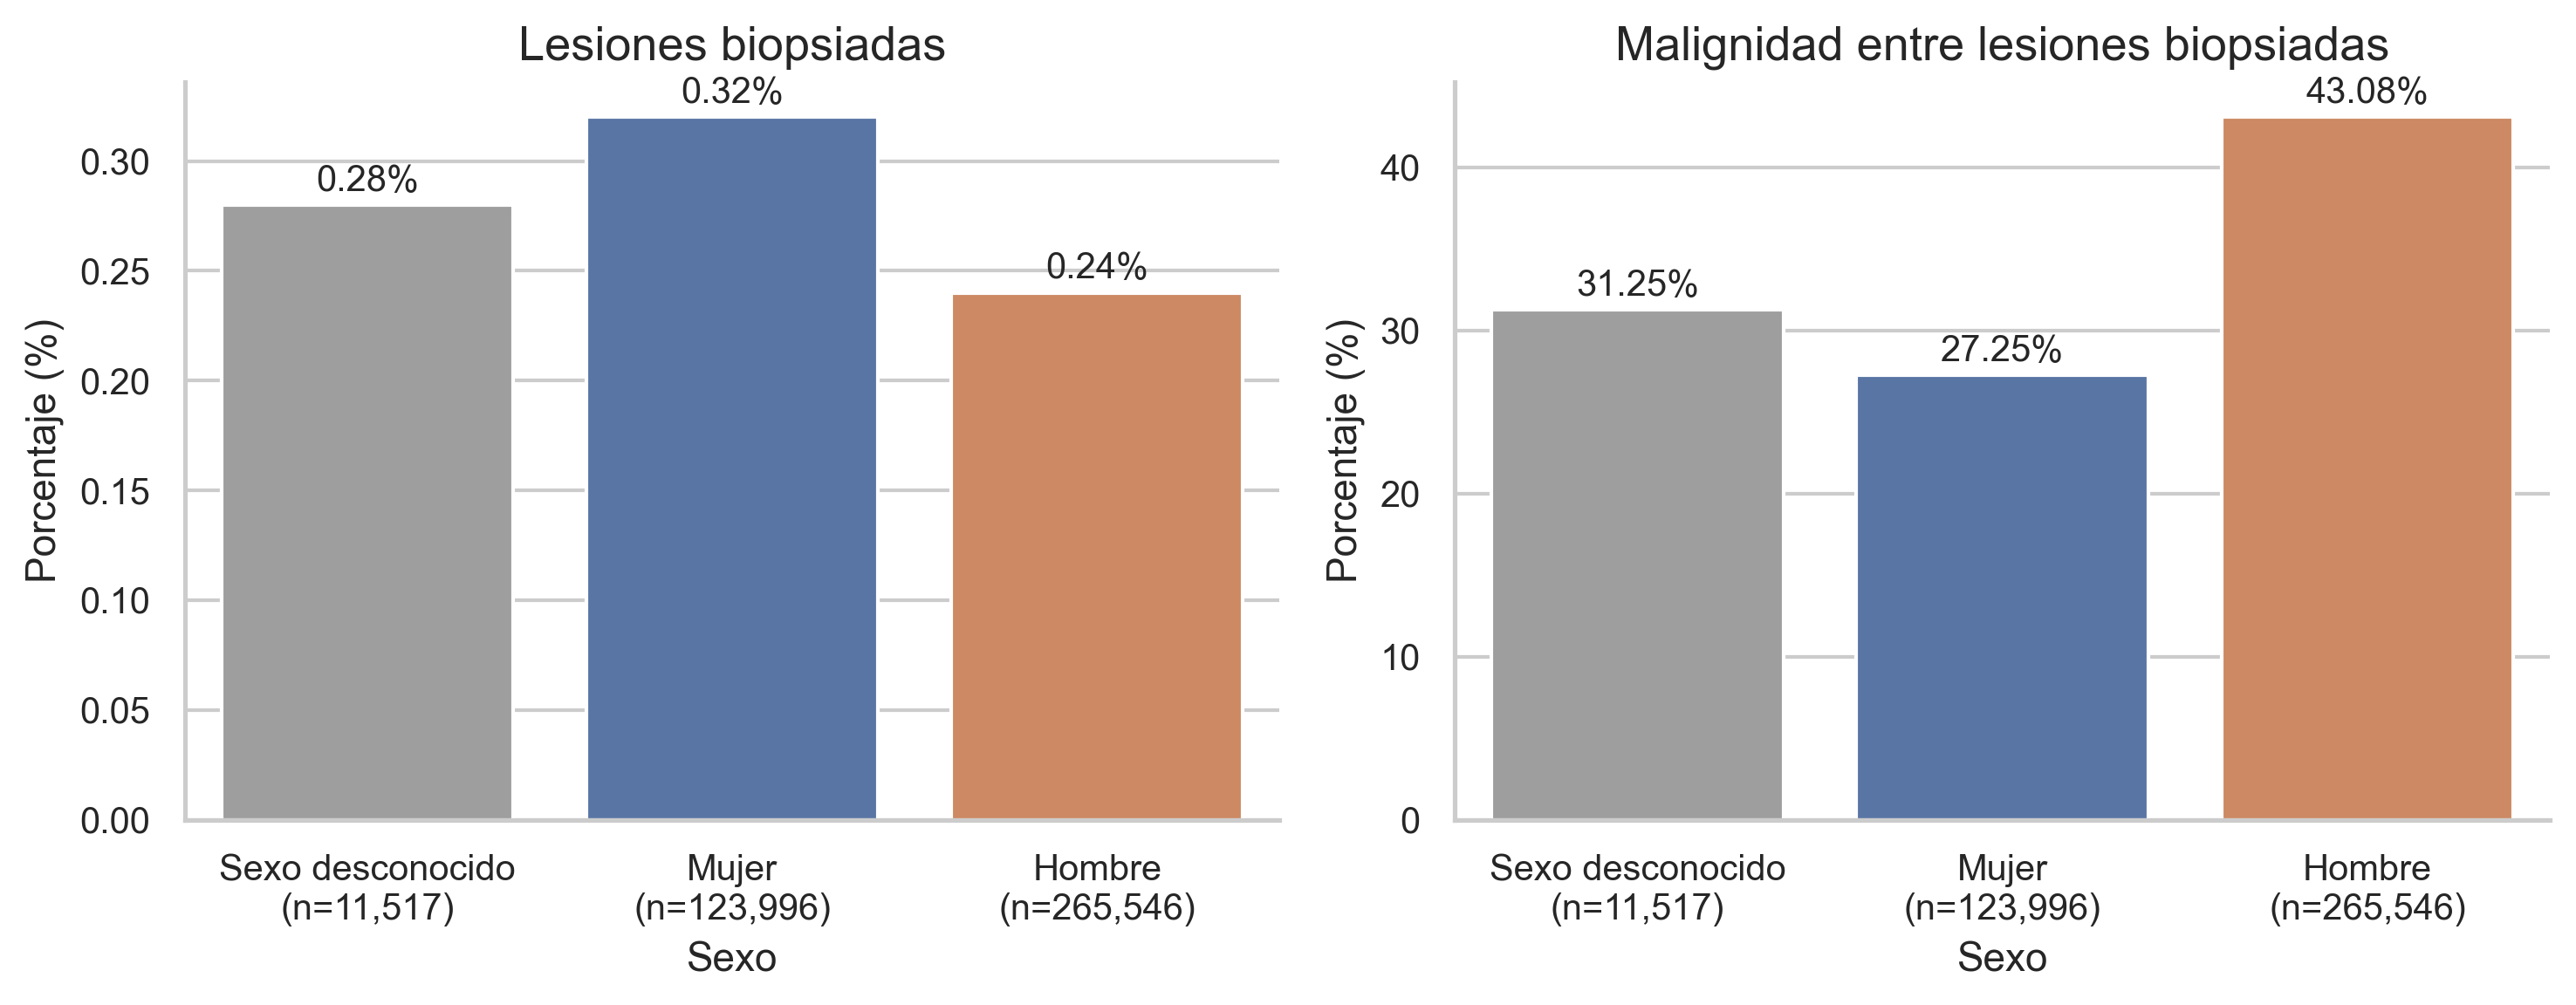

In [78]:
# Predictive value of sex

fig, axes = plt.subplots(
    1,
    2,
    figsize=(10, 4),
)

# Biopsy rate
sns.barplot(
    data=sex_predictive_plot_df,
    x="sex_display",
    y="biopsied_pct",
    hue="sex",
    palette=SEX_PALETTE,
    legend=False,
    ax=axes[0],
)

add_bar_labels(
    axes[0],
    fmt="{:.2f}",
    suffix="%",
)

clean_axis_labels(
    axes[0],
    xlabel="Sexo",
    ylabel="Porcentaje (%)",
    title="Lesiones biopsiadas",
)

# Malignancy rate among biopsied lesions
sns.barplot(
    data=sex_predictive_plot_df,
    x="sex_display",
    y="malignant_pct",
    hue="sex",
    palette=SEX_PALETTE,
    legend=False,
    ax=axes[1],
)

add_bar_labels(
    axes[1],
    fmt="{:.2f}",
    suffix="%",
)

clean_axis_labels(
    axes[1],
    xlabel="Sexo",
    ylabel="Porcentaje (%)",
    title="Malignidad entre lesiones biopsiadas",
)

plt.tight_layout()
plt.show()

figures["sex_predictive_value"] = fig

In [ ]:
# save_plot(
#     figures["sex_predictive_value"],
#     name="sex_predictive_value_biopsy_and_malignancy",
#     subfolder="EDA",
# )

#### Missing sex by attribution

In [70]:
# Plot data: missing sex by attribution

sex_missing_attribution_plot_df = attribution_patient_summary.reset_index().copy()

sex_missing_attribution_plot_df["attribution_label"] = simplify_attribution_series(
    sex_missing_attribution_plot_df["attribution"]
)

sex_missing_attribution_plot_df["label"] = (
    sex_missing_attribution_plot_df["pct_missing_patients"].map("{:.2f}%".format)
    + " ("
    + sex_missing_attribution_plot_df["missing_patients"].astype(int).astype(str)
    + "/"
    + sex_missing_attribution_plot_df["n_patients"].astype(int).astype(str)
    + ")"
)

sex_missing_attribution_plot_df = sex_missing_attribution_plot_df.sort_values(
    "pct_missing_patients",
    ascending=True,
)

attribution_legend = (
    sex_missing_attribution_plot_df[["attribution_label", "attribution"]]
    .drop_duplicates()
    .sort_values("attribution_label")
)

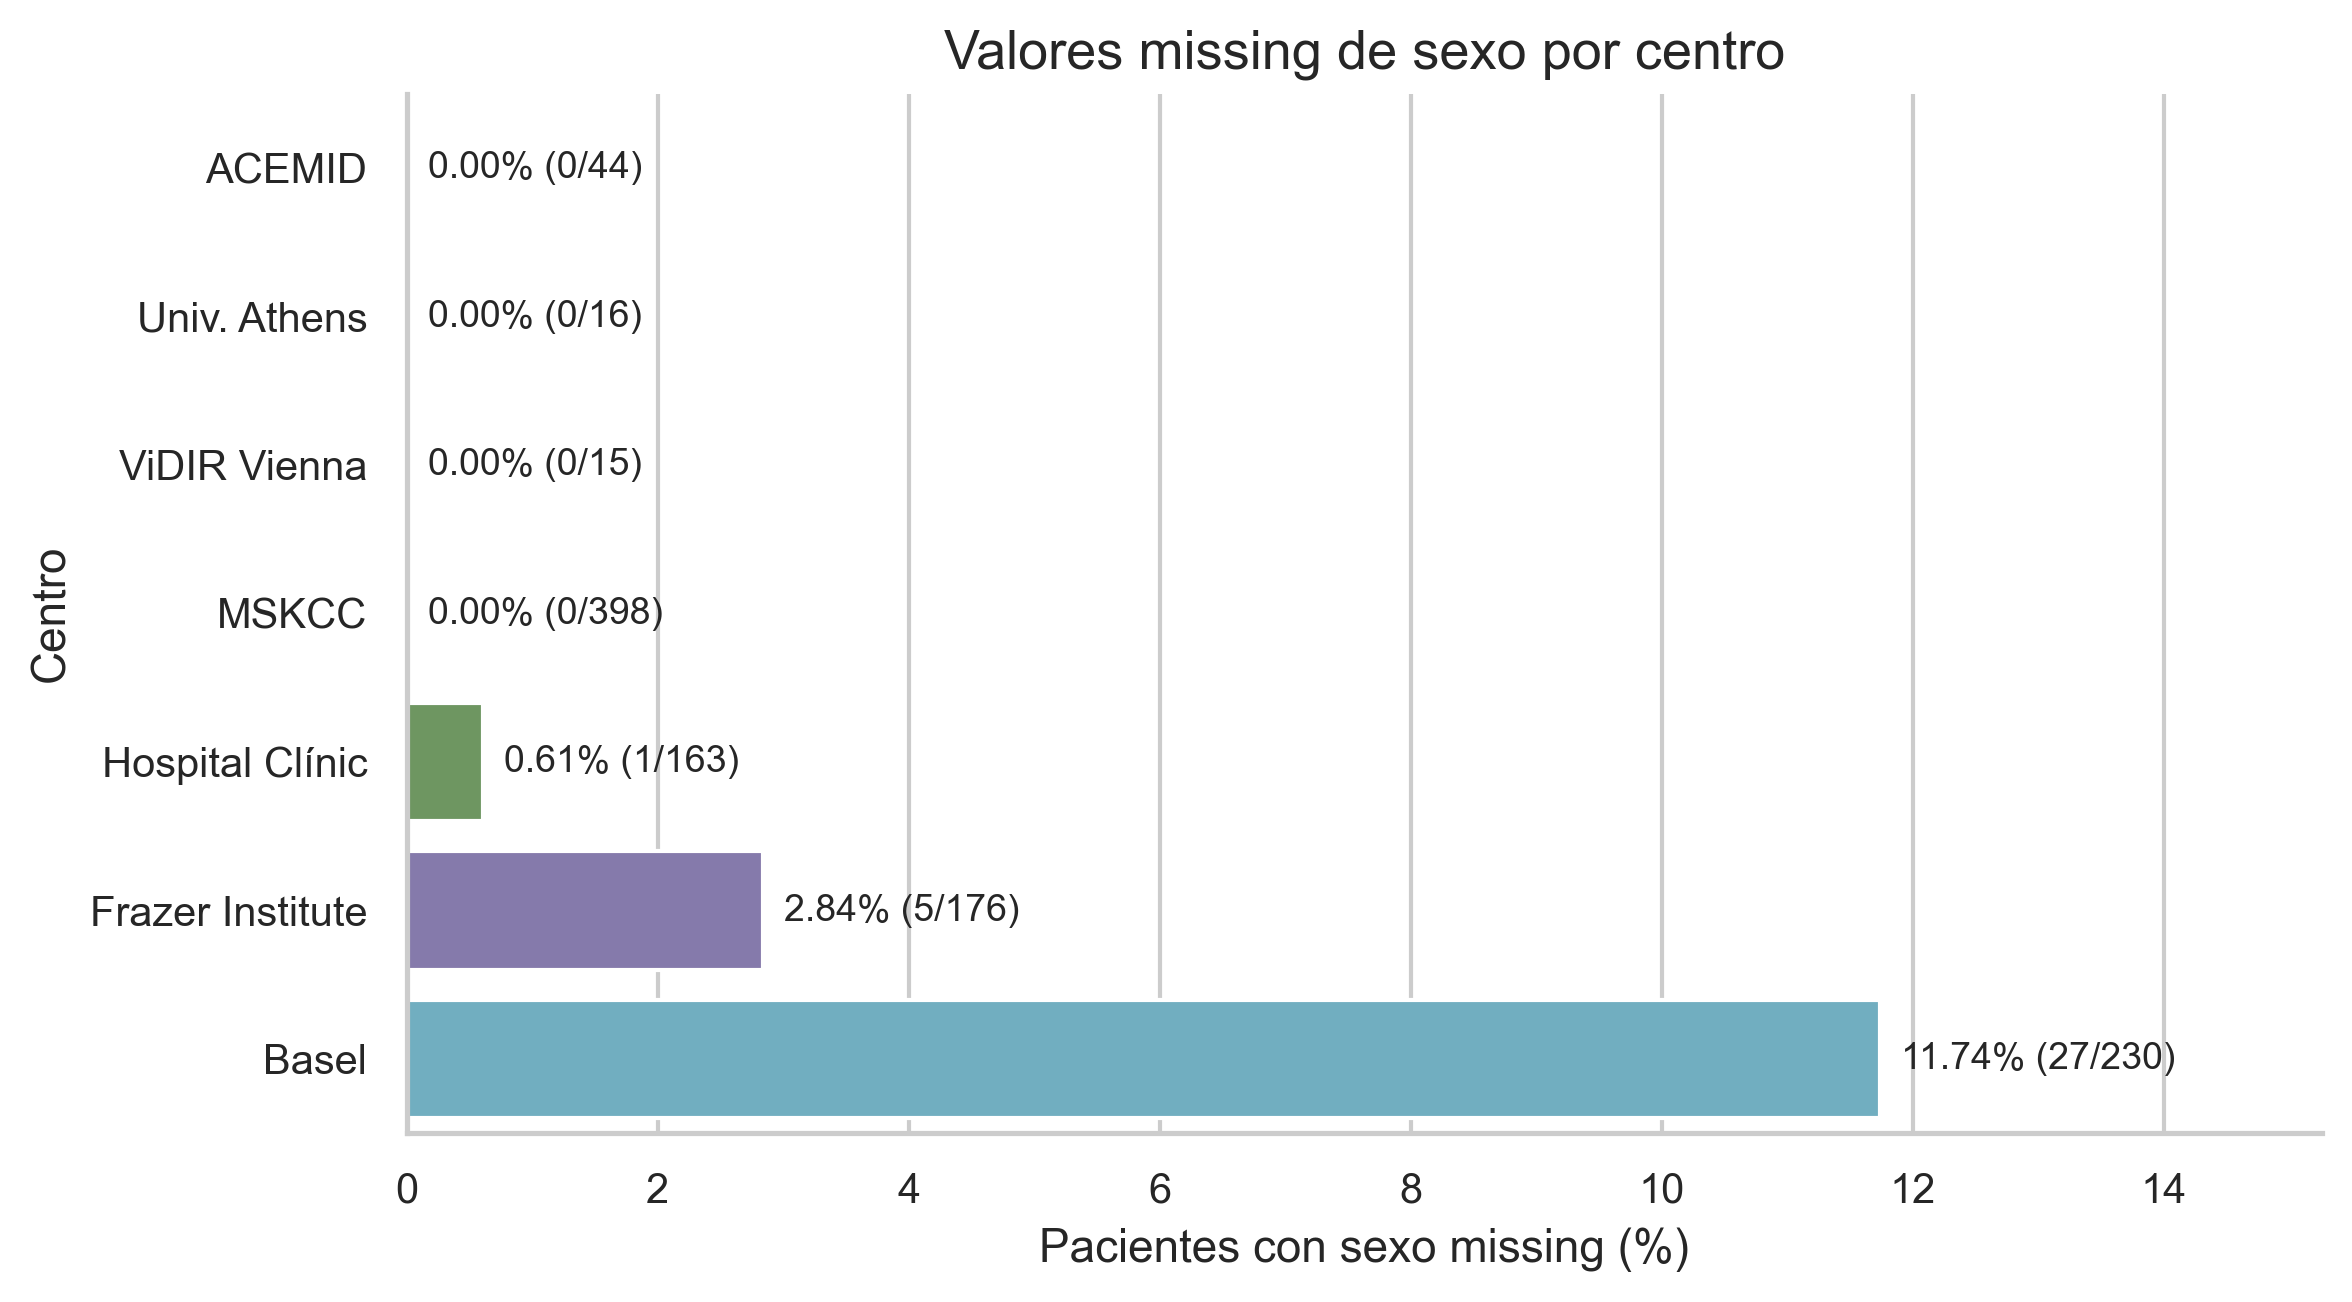

In [75]:
# Missing sex by attribution

fig, ax = plt.subplots(
    figsize=(8, 4.5),
)

sns.barplot(
    data=sex_missing_attribution_plot_df,
    x="pct_missing_patients",
    y="attribution_label",
    hue="attribution_label",
    palette=ATTRIBUTION_PALETTE,
    legend=False,
    ax=ax,
)

# Add percentage and count labels
for patch, (_, row) in zip(
    ax.patches,
    sex_missing_attribution_plot_df.iterrows(),
):
    width = patch.get_width()

    ax.annotate(
        row["label"],
        xy=(
            width,
            patch.get_y() + patch.get_height() / 2,
        ),
        xytext=(5, 0),
        textcoords="offset points",
        ha="left",
        va="center",
        fontsize=9,
    )

clean_axis_labels(
    ax,
    xlabel="Pacientes con sexo missing (%)",
    ylabel="Centro",
    title="Valores missing de sexo por centro",
)

ax.set_xlim(
    0,
    sex_missing_attribution_plot_df["pct_missing_patients"].max() * 1.30,
)

plt.tight_layout()
plt.show()

figures["sex_missing_attribution"] = fig

# AGE

### 1) BASIC DESCRIPTION

In [80]:
df["age_approx"].dtype

dtype('float64')

In [3]:
df["age_approx"].describe()

count    398261.000000
mean         58.012986
std          13.596165
min           5.000000
25%          50.000000
50%          60.000000
75%          70.000000
max          85.000000
Name: age_approx, dtype: float64

| Atributo               | Valor                                             |
| ---------------------- | ------------------------------------------------- |
| Nombre de la variable  | `age_approx`                                      |
| Tipo de variable       | Cuantitativa                                      |
| Subtipo                | Continua discretizada                             |
| Tipo de almacenamiento | `float`                                           |
| Rango de valores       | 5–85 años                                         |
| Presencia de missing   | Sí (`NA`)                                         |
| Nivel de observación   | Variable de paciente registrada a nivel de lesión |

### 2) MISSING VALUES

| Aspecto evaluado                               | Resultado                                                                       |
| ---------------------------------------------- | ------------------------------------------------------------------------------- |
| Lesiones con `age_approx` missing              | 2,798 / 401,059 (0.70%)                                                         |
| Pacientes afectados                            | 13 / 1,042 (1.25%)                                                              |
| Patrón paciente-lesión                         | Los 13 pacientes presentan edad missing en todas sus lesiones                   |
| Centros afectados                              | Hospital Clínic, Frazer Institute y Basel                                       |
| Solapamiento con `sex` missing                 | 2 pacientes                                                                     |
| Solapamiento con localización missing completa | 2 pacientes                                                                     |
| Composición diagnóstica                        | 2,794 `benign_non_biopsied`, 1 `indeterminate_biopsied`, 3 `malignant_biopsied` |


In [10]:
# Missing-age flag at lesion level
df_age = df.assign(age_missing=df["age_approx"].isna())

# General dataset counts
n_lesions_total = len(df_age)
n_patients_total = df_age["patient_id"].nunique()

# Patients with missing age
patients_missing_age = (
    df_age.loc[df_age["age_missing"], "patient_id"].drop_duplicates().sort_values()
)

n_lesions_missing_age = df_age["age_missing"].sum()
n_patients_missing_age = patients_missing_age.nunique()

patients_missing_age.tolist()

['IP_0212694',
 'IP_0362830',
 'IP_1076642',
 'IP_1129512',
 'IP_3371534',
 'IP_3374234',
 'IP_3647018',
 'IP_6659956',
 'IP_6865940',
 'IP_7013759',
 'IP_7848492',
 'IP_7858959',
 'IP_9652562']

In [12]:
age_missing_patient_pattern = (
    df_age.groupby("patient_id")
    .agg(
        n_lesions=("isic_id", "size"),
        n_lesions_missing_age=("age_missing", "sum"),
    )
    .assign(
        all_lesions_missing_age=lambda x: x["n_lesions"].eq(x["n_lesions_missing_age"])
    )
    .loc[patients_missing_age]
    .reset_index()
)

print(age_missing_patient_pattern)

    patient_id  n_lesions  n_lesions_missing_age  all_lesions_missing_age
0   IP_0212694        319                    319                     True
1   IP_0362830         93                     93                     True
2   IP_1076642         47                     47                     True
3   IP_1129512         53                     53                     True
4   IP_3371534        903                    903                     True
5   IP_3374234          7                      7                     True
6   IP_3647018         86                     86                     True
7   IP_6659956         13                     13                     True
8   IP_6865940         24                     24                     True
9   IP_7013759        369                    369                     True
10  IP_7848492        687                    687                     True
11  IP_7858959          8                      8                     True
12  IP_9652562        189             

In [14]:
age_missing_by_attribution = (
    df_age.groupby("attribution")
    .agg(
        n_lesions_total=("isic_id", "size"),
        n_patients_total=("patient_id", "nunique"),
        n_lesions_missing_age=("age_missing", "sum"),
    )
    .reset_index()
)

# Number of affected patients by institution
missing_patients_by_attribution = (
    df_age.loc[df_age["age_missing"]]
    .groupby("attribution")["patient_id"]
    .nunique()
    .rename("n_patients_missing_age")
    .reset_index()
)

age_missing_by_attribution = (
    age_missing_by_attribution.merge(
        missing_patients_by_attribution,
        on="attribution",
        how="left",
    )
    .fillna({"n_patients_missing_age": 0})
    .assign(
        n_patients_missing_age=lambda x: x["n_patients_missing_age"].astype(int),
        perc_lesions_missing_age=lambda x: 100
        * x["n_lesions_missing_age"]
        / x["n_lesions_total"],
        perc_patients_missing_age=lambda x: 100
        * x["n_patients_missing_age"]
        / x["n_patients_total"],
    )
    .sort_values("perc_patients_missing_age", ascending=False)
)

print(age_missing_by_attribution)

                                         attribution  n_lesions_total  \
3  Frazer Institute, The University of Queensland...            51768   
1  Department of Dermatology, Hospital Clínic de ...           105724   
5                       University Hospital of Basel            65218   
2  Department of Dermatology, University of Athen...             7976   
0                                         ACEMID MIA            28665   
4             Memorial Sloan Kettering Cancer Center           129068   
6  ViDIR Group, Department of Dermatology, Medica...            12640   

   n_patients_total  n_lesions_missing_age  n_patients_missing_age  \
3               176                   1205                       5   
1               163                   1461                       4   
5               230                    132                       4   
2                16                      0                       0   
0                44                      0                       

In [15]:
patients_missing_sex = set(df_age.loc[df_age["sex"].isna(), "patient_id"].unique())

patients_missing_age_set = set(patients_missing_age)

patients_missing_age_and_sex = sorted(patients_missing_age_set & patients_missing_sex)

print(patients_missing_age_and_sex)

['IP_3371534', 'IP_7858959']


In [16]:
anatom_site_missing_by_patient = df_age.groupby("patient_id")[
    "anatom_site_general"
].agg(
    n_lesions="size",
    n_missing=lambda x: x.isna().sum(),
)

patients_all_anatom_site_missing = set(
    anatom_site_missing_by_patient.query("n_lesions == n_missing").index
)

patients_missing_age_and_anatom_site = sorted(
    patients_missing_age_set & patients_all_anatom_site_missing
)

print(patients_missing_age_and_anatom_site)

['IP_3374234', 'IP_7858959']


In [17]:
age_missing_diagnostic_summary = (
    df_age.loc[df_age["age_missing"]]
    .groupby("diagnostic_group")
    .size()
    .rename("n_lesions")
    .reset_index()
    .assign(percentage=lambda x: 100 * x["n_lesions"] / x["n_lesions"].sum())
    .sort_values("n_lesions", ascending=False)
)

print(age_missing_diagnostic_summary)

         diagnostic_group  n_lesions  percentage
1     benign_non_biopsied       2790   99.714081
0         benign_biopsied          4    0.142959
3      malignant_biopsied          3    0.107219
2  indeterminate_biopsied          1    0.035740


In [20]:
df_age = df_age.assign(
    biopsy_target=np.where(
        df_age["diagnostic_group"].eq("benign_non_biopsied"),
        "non_biopsied_benign",
        "biopsied",
    )
)

age_missing_impact_h1 = (
    df_age.groupby("biopsy_target")
    .agg(
        n_lesions_total=("isic_id", "size"),
        n_lesions_removed=("age_missing", "sum"),
        n_patients_total=("patient_id", "nunique"),
    )
    .reset_index()
)

h1_patients_removed = (
    df_age.loc[df_age["age_missing"]]
    .groupby("biopsy_target")["patient_id"]
    .nunique()
    .rename("n_patients_removed")
    .reset_index()
)

age_missing_impact_h1 = (
    age_missing_impact_h1.merge(h1_patients_removed, on="biopsy_target", how="left")
    .fillna({"n_patients_removed": 0})
    .assign(
        n_patients_removed=lambda x: x["n_patients_removed"].astype(int),
        perc_lesions_removed=lambda x: 100
        * x["n_lesions_removed"]
        / x["n_lesions_total"],
        perc_patients_removed=lambda x: 100
        * x["n_patients_removed"]
        / x["n_patients_total"],
    )
)

print(age_missing_impact_h1)

         biopsy_target  n_lesions_total  n_lesions_removed  n_patients_total  \
0             biopsied             1068                  8               660   
1  non_biopsied_benign           399991               2790              1040   

   n_patients_removed  perc_lesions_removed  perc_patients_removed  
0                   5              0.749064               0.757576  
1                  13              0.697516               1.250000  


In [21]:
df_biopsied_age = df_age.loc[
    df_age["diagnostic_group"].isin(
        [
            "benign_biopsied",
            "indeterminate_biopsied",
            "malignant_biopsied",
        ]
    )
].assign(
    malignancy_target=lambda x: np.where(
        x["diagnostic_group"].eq("malignant_biopsied"),
        "malignant",
        "non_malignant",
    )
)

age_missing_impact_h2 = (
    df_biopsied_age.groupby("malignancy_target")
    .agg(
        n_lesions_total=("isic_id", "size"),
        n_lesions_removed=("age_missing", "sum"),
        n_patients_total=("patient_id", "nunique"),
    )
    .reset_index()
)

h2_patients_removed = (
    df_biopsied_age.loc[df_biopsied_age["age_missing"]]
    .groupby("malignancy_target")["patient_id"]
    .nunique()
    .rename("n_patients_removed")
    .reset_index()
)

age_missing_impact_h2 = (
    age_missing_impact_h2.merge(h2_patients_removed, on="malignancy_target", how="left")
    .fillna({"n_patients_removed": 0})
    .assign(
        n_patients_removed=lambda x: x["n_patients_removed"].astype(int),
        perc_lesions_removed=lambda x: 100
        * x["n_lesions_removed"]
        / x["n_lesions_total"],
        perc_patients_removed=lambda x: 100
        * x["n_patients_removed"]
        / x["n_patients_total"],
    )
)

print(age_missing_impact_h2)

  malignancy_target  n_lesions_total  n_lesions_removed  n_patients_total  \
0         malignant              393                  3               259   
1     non_malignant              675                  5               475   

   n_patients_removed  perc_lesions_removed  perc_patients_removed  
0                   3              0.763359               1.158301  
1                   2              0.740741               0.421053  


In [30]:
# Patient-level dataset for missingness analysis

patient_level = (
    df_age.groupby("patient_id")
    .agg(
        age_missing=("age_missing", "all"),
        attribution=("attribution", "first"),
        sex=("sex", "first"),
        n_lesions=("isic_id", "size"),
        diagnostic_group_mode=(
            "diagnostic_group",
            lambda x: x.mode().iloc[0] if not x.mode().empty else np.nan,
        ),
        all_anatom_site_missing=(
            "anatom_site_general",
            lambda x: x.isna().all(),
        ),
    )
    .reset_index()
)

patient_level["sex_missing"] = patient_level["sex"].isna()

# Comparison of missing-age vs available-age patients

missingness_comparison = pd.DataFrame(
    {
        "Metric": [
            "Number of patients",
            "Median lesions per patient",
            "IQR lesions per patient",
            "Sex missing (%)",
            "Anatomical site missing in all lesions (%)",
        ],
        "Age available": [
            (~patient_level["age_missing"]).sum(),
            patient_level.loc[~patient_level["age_missing"], "n_lesions"].median(),
            (
                patient_level.loc[~patient_level["age_missing"], "n_lesions"].quantile(
                    0.75
                )
                - patient_level.loc[
                    ~patient_level["age_missing"], "n_lesions"
                ].quantile(0.25)
            ),
            100
            * patient_level.loc[~patient_level["age_missing"], "sex_missing"].mean(),
            100
            * patient_level.loc[
                ~patient_level["age_missing"], "all_anatom_site_missing"
            ].mean(),
        ],
        "Age missing": [
            patient_level["age_missing"].sum(),
            patient_level.loc[patient_level["age_missing"], "n_lesions"].median(),
            (
                patient_level.loc[patient_level["age_missing"], "n_lesions"].quantile(
                    0.75
                )
                - patient_level.loc[patient_level["age_missing"], "n_lesions"].quantile(
                    0.25
                )
            ),
            100 * patient_level.loc[patient_level["age_missing"], "sex_missing"].mean(),
            100
            * patient_level.loc[
                patient_level["age_missing"], "all_anatom_site_missing"
            ].mean(),
        ],
    }
)

print(missingness_comparison)

                                       Metric  Age available  Age missing
0                          Number of patients    1029.000000    13.000000
1                  Median lesions per patient     242.000000    86.000000
2                     IQR lesions per patient     363.000000   295.000000
3                             Sex missing (%)       3.012634    15.384615
4  Anatomical site missing in all lesions (%)       0.874636    15.384615


In [32]:
# Distribution by dominant diagnostic group

age_missing_by_diagnostic_group = (
    patient_level.groupby(["diagnostic_group_mode", "age_missing"])
    .size()
    .unstack(fill_value=0)
    .rename(columns={False: "age_available", True: "age_missing"})
)

age_missing_by_diagnostic_group["total"] = (
    age_missing_by_diagnostic_group["age_available"]
    + age_missing_by_diagnostic_group["age_missing"]
)

age_missing_by_diagnostic_group["perc_age_missing"] = (
    100
    * age_missing_by_diagnostic_group["age_missing"]
    / age_missing_by_diagnostic_group["total"]
)

age_missing_by_diagnostic_group.sort_values(
    "perc_age_missing",
    ascending=False,
)

print(age_missing_by_diagnostic_group)

age_missing            age_available  age_missing  total  perc_age_missing
diagnostic_group_mode                                                     
benign_non_biopsied             1027           13   1040              1.25
malignant_biopsied                 2            0      2              0.00


#### Análisis de valores missing en `age_approx`

| Nivel de análisis            |                  Total | Registros con `age_approx` missing | % missing | Comentario                                                        |
| ---------------------------- | ---------------------: | ---------------------------------: | --------: | ----------------------------------------------------------------- |
| Lesión                       |                401,059 |                              2,798 |     0.70% | Lesiones sin información sobre la edad aproximada del paciente    |
| Paciente                     |                  1,042 |                                 13 |     1.25% | Pacientes sin ninguna edad registrada                             |
| Consistencia paciente-lesión | 13 pacientes afectados |  13 con todas sus lesiones missing |   100.00% | La ausencia de edad es completa y consistente dentro del paciente |

La variable `age_approx` presenta valores *missing* en 2,798 lesiones, equivalentes al 0.70% del conjunto de datos. A nivel de paciente, estos registros corresponden a 13 de los 1,042 pacientes disponibles, lo que representa un 1.25% de la cohorte.

Dado que la edad es una característica del paciente registrada en el momento de adquisición de cada lesión, se evaluó la consistencia de su ausencia dentro de cada individuo. Los 13 pacientes afectados presentan `age_approx` missing en la totalidad de sus lesiones, sin observarse ningún caso de ausencia parcial. Por tanto, la información no puede recuperarse utilizando otras lesiones del mismo paciente.

#### Exploración del mecanismo de missingness

La ausencia de edad no se distribuye homogéneamente entre las distintas fuentes de datos. Los 13 pacientes afectados proceden exclusivamente de tres instituciones:

| Institución                                     | Pacientes con edad missing | Pacientes totales | % de pacientes afectados | Lesiones con edad missing |
| ----------------------------------------------- | -------------------------: | ----------------: | -----------------------: | ------------------------: |
| Frazer Institute / The University of Queensland |                          5 |               176 |                    2.84% |                     1,205 |
| Hospital Clínic de Barcelona                    |                          4 |               163 |                    2.45% |                     1,461 |
| University Hospital of Basel                    |                          4 |               230 |                    1.74% |                       132 |

Los cuatro centros restantes no presentan ningún paciente con información de edad ausente. Esta concentración por institución sugiere que el missingness podría estar relacionado con diferencias en los procedimientos de recogida, anonimización o integración de los datos.

Además, se compararon algunas características observadas entre los pacientes con edad disponible y los pacientes con edad missing:

| Característica                                                     | Edad disponible | Edad missing |
| ------------------------------------------------------------------ | --------------: | -----------: |
| Número de pacientes                                                |           1,029 |           13 |
| Mediana de lesiones por paciente                                   |             242 |           86 |
| IQR de lesiones por paciente                                       |             363 |          295 |
| Pacientes con `sex` missing                                        |           3.01% |       15.38% |
| Pacientes con localización anatómica missing en todas sus lesiones |           0.87% |       15.38% |

Los pacientes con edad missing presentan con mayor frecuencia ausencia simultánea de información en `sex` y en la localización anatómica. Esto refuerza la hipótesis de que la falta de edad forma parte de un problema más general de completitud de metadatos en determinados pacientes o fuentes de datos, y no de una ausencia aislada de esta variable.

El número de lesiones por paciente también es inferior en el grupo con edad missing, aunque existe una variabilidad considerable dentro de ambos grupos. Dado el reducido número de pacientes afectados, esta diferencia debe interpretarse con cautela.

En cuanto a la composición diagnóstica, las 2,798 lesiones afectadas se distribuyen de la siguiente manera:

| Categoría diagnóstica    | Lesiones | Porcentaje |
| ------------------------ | -------: | ---------: |
| `benign_non_biopsied`    |    2,794 |     99.86% |
| `indeterminate_biopsied` |        1 |      0.04% |
| `malignant_biopsied`     |        3 |      0.11% |
| `benign_biopsied`        |        0 |      0.00% |

Por tanto, la ausencia de edad se concentra casi exclusivamente en lesiones benignas no biopsiadas. No obstante, esta distribución debe interpretarse teniendo en cuenta el fuerte predominio de esta categoría en el conjunto de datos completo.

#### Tipo de missingness probable

No es posible determinar de forma definitiva el mecanismo de missingness únicamente a partir de los datos observados. En particular, no puede evaluarse si la probabilidad de ausencia depende de la edad real, ya que esta no se conoce en los pacientes afectados.

Sin embargo, los resultados muestran que:

* los valores missing están concentrados en determinadas instituciones;
* existe un mayor solapamiento con otras variables missing;
* la ausencia es completa a nivel de paciente;
* no parece tratarse de errores aislados a nivel de lesión.

Por tanto, el patrón observado no parece compatible con un mecanismo estrictamente **Missing Completely At Random (MCAR)**. Los resultados son más consistentes con un mecanismo **Missing At Random (MAR)** condicionado por variables observadas, principalmente `attribution` y la disponibilidad general de metadatos.

No obstante, esta clasificación debe considerarse una hipótesis razonable y no una demostración formal. Tampoco puede descartarse completamente un componente **Missing Not At Random (MNAR)** relacionado con características no observadas o con el proceso original de recogida de la edad.

#### Posibles estrategias de tratamiento

Una primera opción sería imputar la edad utilizando información observada, por ejemplo:

* la mediana de edad global;
* la mediana de edad del centro de procedencia;
* un modelo de imputación basado en `attribution`, `sex`, localización anatómica y otras variables clínicas;
* imputación múltiple para incorporar la incertidumbre asociada.

Sin embargo, en este caso la imputación presenta varias limitaciones. La edad está completamente ausente para todas las lesiones de los pacientes afectados, por lo que no existe información longitudinal o intra-paciente que permita recuperarla. Además, la fuerte discretización de la variable y la concentración del missingness por centro podrían hacer que una imputación simple introdujera valores artificiales excesivamente determinados por la fuente de datos.

La segunda opción es excluir los 13 pacientes afectados. El impacto global de esta decisión sería reducido:

| Escenario                                | Pacientes (n) | Pacientes (%) | Lesiones (n) | Lesiones (%) |
| ---------------------------------------- | ------------: | ------------: | -----------: | -----------: |
| Dataset original                         |         1,042 |       100.00% |      401,059 |      100.00% |
| Tras eliminar pacientes con edad missing |         1,029 |        98.75% |      398,261 |       99.30% |
| Registros eliminados                     |            13 |         1.25% |        2,798 |        0.70% |

Respecto a las hipótesis de modelado:

* En el modelo de recomendación de biopsia se eliminarían 2,794 lesiones de la clase `benign_non_biopsied` y únicamente 4 lesiones de la clase biopsiada.
* En el modelo de malignidad restringido a lesiones biopsiadas se eliminarían 1 lesión no maligna y 3 lesiones malignas.

#### Decisión propuesta

Dado el pequeño número de pacientes afectados, la ausencia completa de edad dentro de cada paciente, la imposibilidad de recuperar la variable a partir de otras lesiones del mismo individuo y la pérdida global limitada de información, la exclusión de estos 13 pacientes constituye una estrategia de preprocesamiento razonable.

Esta decisión evita introducir edades artificiales mediante imputación y simplifica la construcción de una cohorte con metadatos completos. No obstante, antes de aplicarla definitivamente, deberá verificarse que la eliminación de las tres lesiones malignas no produzca un cambio relevante en la distribución de clases del modelo secundario de malignidad.

Por motivos de trazabilidad, los pacientes afectados son:

`IP_0212694`, `IP_0362830`, `IP_1076642`, `IP_1129512`, `IP_3371534`, `IP_3374234`, `IP_3647018`, `IP_6659956`, `IP_6865940`, `IP_7013759`, `IP_7848492`, `IP_7858959` e `IP_9652562`.


### 3) DISTRIBUTION AND CLASSIFCIATION

In [35]:
# Patient-level age summary

patient_age = (
    df.groupby("patient_id")
    .agg(
        age_min=("age_approx", "min"),
        age_max=("age_approx", "max"),
        n_unique_ages=("age_approx", lambda x: x.nunique(dropna=True)),
        n_lesions=("isic_id", "size"),
    )
    .reset_index()
)

patient_age["age_range"] = patient_age["age_max"] - patient_age["age_min"]

# Representative age for patient-level analyses
patient_age["age_patient"] = patient_age[["age_min", "age_max"]].mean(axis=1)

# Consistency checks

age_consistency_summary = (
    patient_age["n_unique_ages"]
    .value_counts(dropna=False)
    .sort_index()
    .rename_axis("n_unique_ages")
    .reset_index(name="n_patients")
)

age_consistency_summary["percentage"] = (
    100 * age_consistency_summary["n_patients"] / patient_age["patient_id"].nunique()
).round(2)

print(age_consistency_summary)

   n_unique_ages  n_patients  percentage
0              0          13        1.25
1              1         929       89.16
2              2         100        9.60


In [36]:
def summarize_numeric(series: pd.Series, level: str) -> pd.DataFrame:
    """Return a complete descriptive summary for a numeric variable."""

    values = series.dropna()

    q1 = values.quantile(0.25)
    q3 = values.quantile(0.75)

    return pd.DataFrame(
        {
            "level": [level],
            "n": [values.size],
            "missing": [series.isna().sum()],
            "n_unique": [values.nunique()],
            "mean": [values.mean()],
            "std": [values.std()],
            "min": [values.min()],
            "q1": [q1],
            "median": [values.median()],
            "q3": [q3],
            "max": [values.max()],
            "iqr": [q3 - q1],
            "skewness": [values.skew()],
            "kurtosis": [values.kurt()],
        }
    )

In [37]:
age_descriptive_summary = pd.concat(
    [
        summarize_numeric(df["age_approx"], level="Lesion level"),
        summarize_numeric(patient_age["age_patient"], level="Patient level"),
    ],
    ignore_index=True,
).round(2)

print(age_descriptive_summary)

           level       n  missing  n_unique   mean    std  min    q1  median  \
0   Lesion level  398261     2798        16  58.01  13.60  5.0  50.0    60.0   
1  Patient level    1029       13        29  52.61  14.92  5.0  40.0    55.0   

     q3   max   iqr  skewness  kurtosis  
0  70.0  85.0  20.0     -0.26     -0.29  
1  65.0  85.0  25.0     -0.20     -0.46  


In [38]:
age_distribution_patient = (
    patient_age["age_patient"]
    .value_counts(dropna=False)
    .sort_index()
    .rename_axis("age")
    .reset_index(name="n_patients")
)

age_distribution_patient["percentage"] = (
    100
    * age_distribution_patient["n_patients"]
    / age_distribution_patient["n_patients"].sum()
).round(2)

print(age_distribution_patient)

     age  n_patients  percentage
0    5.0           1        0.10
1   15.0           7        0.67
2   20.0          16        1.54
3   22.5           3        0.29
4   25.0          25        2.40
5   27.5           1        0.10
6   30.0          55        5.28
7   32.5           1        0.10
8   35.0          58        5.57
9   37.5           4        0.38
10  40.0         103        9.88
11  42.5          10        0.96
12  45.0          75        7.20
13  47.5          12        1.15
14  50.0         107       10.27
15  52.5          13        1.25
16  55.0         119       11.42
17  57.5          19        1.82
18  60.0         104        9.98
19  62.5          16        1.54
20  65.0         113       10.84
21  67.5           9        0.86
22  70.0          67        6.43
23  72.5           6        0.58
24  75.0          40        3.84
25  77.5           5        0.48
26  80.0          28        2.69
27  82.5           1        0.10
28  85.0          11        1.06
29   NaN  

In [39]:
age_distribution_lesion = (
    df["age_approx"]
    .value_counts(dropna=False)
    .sort_index()
    .rename_axis("age")
    .reset_index(name="n_lesions")
)

age_distribution_lesion["percentage"] = (
    100
    * age_distribution_lesion["n_lesions"]
    / age_distribution_lesion["n_lesions"].sum()
).round(2)

print(age_distribution_lesion)

     age  n_lesions  percentage
0    5.0          1        0.00
1   15.0        644        0.16
2   20.0       1742        0.43
3   25.0       3433        0.86
4   30.0      10400        2.59
5   35.0      11543        2.88
6   40.0      31297        7.80
7   45.0      23580        5.88
8   50.0      47924       11.95
9   55.0      58123       14.49
10  60.0      54109       13.49
11  65.0      54946       13.70
12  70.0      39775        9.92
13  75.0      30801        7.68
14  80.0      21096        5.26
15  85.0       8847        2.21
16   NaN       2798        0.70


In [40]:
def detect_iqr_outliers(series: pd.Series) -> dict:
    """Identify outliers using the 1.5 × IQR rule."""

    values = series.dropna()

    q1 = values.quantile(0.25)
    q3 = values.quantile(0.75)
    iqr = q3 - q1

    lower_bound = q1 - 1.5 * iqr
    upper_bound = q3 + 1.5 * iqr

    outliers = values[(values < lower_bound) | (values > upper_bound)]

    return {
        "q1": q1,
        "q3": q3,
        "iqr": iqr,
        "lower_bound": lower_bound,
        "upper_bound": upper_bound,
        "n_outliers": len(outliers),
        "percentage_outliers": 100 * len(outliers) / len(values),
        "outlier_values": sorted(outliers.unique()),
    }

In [41]:
age_outliers_lesion = detect_iqr_outliers(df["age_approx"])
age_outliers_patient = detect_iqr_outliers(patient_age["age_patient"])

age_outlier_summary = pd.DataFrame(
    [
        {"level": "Lesion level", **age_outliers_lesion},
        {"level": "Patient level", **age_outliers_patient},
    ]
)

print(age_outlier_summary)

           level    q1    q3   iqr  lower_bound  upper_bound  n_outliers  \
0   Lesion level  50.0  70.0  20.0         20.0        100.0         645   
1  Patient level  40.0  65.0  25.0          2.5        102.5           0   

   percentage_outliers outlier_values  
0             0.161954    [5.0, 15.0]  
1             0.000000             []  


In [44]:
df_age_model = df.loc[df["age_approx"].notna()].copy()

In [48]:
# Hypothesis 1: biopsy recommendation

df_age_model["biopsy_target"] = np.where(
    df_age_model["diagnostic_group"].eq("benign_non_biopsied"),
    0,
    1,
)

df_age_model["biopsy_group"] = np.where(
    df_age_model["biopsy_target"].eq(0),
    "Non-biopsied benign",
    "Biopsied",
)

In [49]:
# Hypothesis 2: malignancy classification among biopsied lesions

df_age_biopsied = df_age_model.loc[
    df_age_model["diagnostic_group"].isin(
        [
            "benign_biopsied",
            "indeterminate_biopsied",
            "malignant_biopsied",
        ]
    )
].copy()

df_age_biopsied["malignancy_target"] = np.where(
    df_age_biopsied["diagnostic_group"].eq("malignant_biopsied"),
    1,
    0,
)

df_age_biopsied["malignancy_group"] = np.where(
    df_age_biopsied["malignancy_target"].eq(1),
    "Malignant",
    "Non-malignant",
)

In [50]:
def summarize_age_by_group(
    data: pd.DataFrame,
    group_col: str,
    cohort_name: str,
) -> pd.DataFrame:
    """Summarize age distribution by classification group."""

    return (
        data.groupby(group_col)["age_approx"]
        .agg(
            n="size",
            mean="mean",
            std="std",
            median="median",
            q1=lambda x: x.quantile(0.25),
            q3=lambda x: x.quantile(0.75),
            min="min",
            max="max",
            skewness="skew",
        )
        .reset_index()
        .assign(
            iqr=lambda x: x["q3"] - x["q1"],
            cohort=cohort_name,
        )
    )

In [52]:
age_summary_h1 = summarize_age_by_group(
    data=df_age_model,
    group_col="biopsy_group",
    cohort_name="Hypothesis 1",
)

age_summary_h2 = summarize_age_by_group(
    data=df_age_biopsied,
    group_col="malignancy_group",
    cohort_name="Hypothesis 2",
)

age_summary_models = pd.concat(
    [age_summary_h1, age_summary_h2], ignore_index=True
).round(2)

print(age_summary_models)

          biopsy_group       n   mean    std  median    q1    q3   min   max  \
0             Biopsied    1060  54.67  14.01    55.0  45.0  65.0  15.0  85.0   
1  Non-biopsied benign  397201  58.02  13.59    60.0  50.0  70.0   5.0  85.0   
2                  NaN     390  61.37  11.93    60.0  55.0  70.0  20.0  85.0   
3                  NaN     670  50.76  13.66    50.0  40.0  60.0  15.0  85.0   

   skewness   iqr        cohort malignancy_group  
0     -0.24  20.0  Hypothesis 1              NaN  
1     -0.26  20.0  Hypothesis 1              NaN  
2     -0.31  15.0  Hypothesis 2        Malignant  
3     -0.14  20.0  Hypothesis 2    Non-malignant  


In [59]:
def rank_biserial_from_mannwhitney(
    group_0: pd.Series,
    group_1: pd.Series,
) -> float:
    """Compute rank-biserial correlation from Mann–Whitney U."""

    x = group_0.dropna()
    y = group_1.dropna()

    u_statistic, _ = stats.mannwhitneyu(
        x,
        y,
        alternative="two-sided",
    )

    return 1 - (2 * u_statistic) / (len(x) * len(y))

In [58]:
def compare_age_groups(
    data: pd.DataFrame,
    target_col: str,
    hypothesis: str,
) -> pd.DataFrame:
    """Compare age between binary target groups."""

    group_0 = data.loc[data[target_col] == 0, "age_approx"]

    group_1 = data.loc[data[target_col] == 1, "age_approx"]

    mann_whitney = stats.mannwhitneyu(
        group_0,
        group_1,
        alternative="two-sided",
    )

    point_biserial = stats.pointbiserialr(
        data[target_col],
        data["age_approx"],
    )

    spearman = stats.spearmanr(
        data["age_approx"],
        data[target_col],
    )

    return pd.DataFrame(
        {
            "hypothesis": [hypothesis],
            "n_group_0": [len(group_0)],
            "n_group_1": [len(group_1)],
            "median_group_0": [group_0.median()],
            "median_group_1": [group_1.median()],
            "mann_whitney_u": [mann_whitney.statistic],
            "mann_whitney_p": [mann_whitney.pvalue],
            "rank_biserial_correlation": [
                rank_biserial_from_mannwhitney(
                    group_0,
                    group_1,
                )
            ],
            "point_biserial_r": [point_biserial.statistic],
            "point_biserial_p": [point_biserial.pvalue],
            "spearman_rho": [spearman.statistic],
            "spearman_p": [spearman.pvalue],
        }
    )

In [61]:
age_association_results = pd.concat(
    [
        compare_age_groups(
            data=df_age_model,
            target_col="biopsy_target",
            hypothesis="Hypothesis 1: biopsy recommendation",
        ),
        compare_age_groups(
            data=df_age_biopsied,
            target_col="malignancy_target",
            hypothesis="Hypothesis 2: malignancy classification",
        ),
    ],
    ignore_index=True,
).round(4)

print(age_association_results)

                                hypothesis  n_group_0  n_group_1  \
0      Hypothesis 1: biopsy recommendation     397201       1060   
1  Hypothesis 2: malignancy classification        670        390   

   median_group_0  median_group_1  mann_whitney_u  mann_whitney_p  \
0            60.0            55.0     237906852.0             0.0   
1            50.0            60.0         74257.0             0.0   

   rank_biserial_correlation  point_biserial_r  point_biserial_p  \
0                    -0.1301           -0.0127               0.0   
1                     0.4316            0.3653               0.0   

   spearman_rho  spearman_p  
0       -0.0117         0.0  
1        0.3627         0.0  


In [62]:
age_biopsy_rate = (
    df_age_model.groupby("age_approx")
    .agg(
        n_lesions=("isic_id", "size"),
        n_biopsied=("biopsy_target", "sum"),
        biopsy_rate=("biopsy_target", "mean"),
        n_patients=("patient_id", "nunique"),
    )
    .reset_index()
)

age_biopsy_rate["biopsy_rate_percentage"] = 100 * age_biopsy_rate["biopsy_rate"]

print(age_biopsy_rate)

    age_approx  n_lesions  n_biopsied  biopsy_rate  n_patients  \
0          5.0          1           0     0.000000           1   
1         15.0        644           1     0.001553           7   
2         20.0       1742          10     0.005741          19   
3         25.0       3433          28     0.008156          29   
4         30.0      10400          40     0.003846          57   
5         35.0      11543          44     0.003812          63   
6         40.0      31297         103     0.003291         117   
7         45.0      23580          90     0.003817          97   
8         50.0      47924         115     0.002400         132   
9         55.0      58123         146     0.002512         151   
10        60.0      54109         152     0.002809         139   
11        65.0      54946         145     0.002639         138   
12        70.0      39775          96     0.002414          82   
13        75.0      30801          42     0.001364          51   
14        

In [63]:
age_malignancy_rate = (
    df_age_biopsied.groupby("age_approx")
    .agg(
        n_biopsied_lesions=("isic_id", "size"),
        n_malignant=("malignancy_target", "sum"),
        malignancy_rate=("malignancy_target", "mean"),
        n_patients=("patient_id", "nunique"),
    )
    .reset_index()
)

age_malignancy_rate["malignancy_rate_percentage"] = (
    100 * age_malignancy_rate["malignancy_rate"]
)

print(age_malignancy_rate)

    age_approx  n_biopsied_lesions  n_malignant  malignancy_rate  n_patients  \
0         15.0                   1            0         0.000000           1   
1         20.0                  10            1         0.100000           9   
2         25.0                  28            2         0.071429          18   
3         30.0                  40            3         0.075000          27   
4         35.0                  44            4         0.090909          31   
5         40.0                 103           15         0.145631          73   
6         45.0                  90           27         0.300000          65   
7         50.0                 115           27         0.234783          78   
8         55.0                 146           46         0.315068          96   
9         60.0                 152           86         0.565789          84   
10        65.0                 145           67         0.462069          93   
11        70.0                  96      

In [65]:
def add_wilson_interval(
    table: pd.DataFrame,
    successes_col: str,
    total_col: str,
) -> pd.DataFrame:
    """Add Wilson 95% confidence intervals for proportions."""

    result = table.copy()

    proportion = result[successes_col] / result[total_col]

    z = 1.96
    denominator = 1 + (z**2 / result[total_col])

    centre = (proportion + z**2 / (2 * result[total_col])) / denominator

    margin = (
        z
        * np.sqrt(
            proportion * (1 - proportion) / result[total_col]
            + z**2 / (4 * result[total_col] ** 2)
        )
        / denominator
    )

    result["ci_lower"] = 100 * (centre - margin)
    result["ci_upper"] = 100 * (centre + margin)

    return result

In [66]:
age_biopsy_rate = add_wilson_interval(
    table=age_biopsy_rate,
    successes_col="n_biopsied",
    total_col="n_lesions",
)

age_malignancy_rate = add_wilson_interval(
    table=age_malignancy_rate,
    successes_col="n_malignant",
    total_col="n_biopsied_lesions",
)
print(age_biopsy_rate)
print(age_malignancy_rate)

    age_approx  n_lesions  n_biopsied  biopsy_rate  n_patients  \
0          5.0          1           0     0.000000           1   
1         15.0        644           1     0.001553           7   
2         20.0       1742          10     0.005741          19   
3         25.0       3433          28     0.008156          29   
4         30.0      10400          40     0.003846          57   
5         35.0      11543          44     0.003812          63   
6         40.0      31297         103     0.003291         117   
7         45.0      23580          90     0.003817          97   
8         50.0      47924         115     0.002400         132   
9         55.0      58123         146     0.002512         151   
10        60.0      54109         152     0.002809         139   
11        65.0      54946         145     0.002639         138   
12        70.0      39775          96     0.002414          82   
13        75.0      30801          42     0.001364          51   
14        

#### Consistencia y nivel de análisis

La variable `age_approx` representa la edad aproximada del paciente en el momento de adquisición de la imagen. Aunque es una característica del paciente, se encuentra registrada a nivel de lesión.

De los 1,042 pacientes incluidos en el conjunto de datos:

* 13 pacientes presentan la edad ausente en todas sus lesiones.
* 929 pacientes presentan un único valor de edad.
* 100 pacientes presentan dos valores de edad distintos, siempre separados por exactamente cinco años.

Estas diferencias son compatibles con imágenes obtenidas durante visitas o periodos de seguimiento diferentes. Por este motivo, se utilizarán dos representaciones de la edad:

* **Análisis y modelado a nivel de lesión:** se conservará el valor original de `age_approx` asociado a cada imagen, ya que representa la edad aproximada del paciente en el momento de adquisición.
* **Análisis descriptivo a nivel de paciente:** se utilizará una única edad representativa. En los pacientes con dos valores, se empleará el punto medio del intervalo para evitar contabilizar al mismo individuo en dos grupos de edad.

#### Estadísticos descriptivos

| Nivel de análisis | n válido | Missing | Valores únicos | Media |    DE | Mediana |   Q1 |   Q3 |  IQR | Mínimo | Máximo | Skewness | Kurtosis |
| ----------------- | -------: | ------: | -------------: | ----: | ----: | ------: | ---: | ---: | ---: | -----: | -----: | -------: | -------: |
| Lesión            |  398,261 |   2,798 |             16 | 58.01 | 13.60 |    60.0 | 50.0 | 70.0 | 20.0 |    5.0 |   85.0 |    -0.26 |    -0.29 |
| Paciente          |    1,029 |      13 |             29 | 52.61 | 14.92 |    55.0 | 40.0 | 65.0 | 25.0 |    5.0 |   85.0 |    -0.20 |    -0.46 |

La diferencia entre los resúmenes a nivel de lesión y de paciente es relevante. La edad media es superior a nivel de lesión, 58.01 frente a 52.61 años, lo que indica que los pacientes de mayor edad aportan, en promedio, un mayor número de imágenes. 

La distribución presenta una ligera asimetría negativa tanto a nivel de lesión como de paciente, con valores de *skewness* próximos a cero. La *kurtosis* también es moderadamente negativa, lo que indica una distribución algo más plana que una distribución normal, pero sin colas especialmente extremas.

En conjunto, estos resultados no muestran una asimetría suficientemente importante como para justificar una transformación logarítmica u otra transformación destinada a corregir la distribución.

#### Evaluación de valores extremos

| Nivel de análisis | Límite inferior IQR | Límite superior IQR | Observaciones identificadas | Porcentaje | Valores     |
| ----------------- | ------------------: | ------------------: | --------------------------: | ---------: | ----------- |
| Lesión            |                20.0 |               100.0 |                         645 |      0.16% | 5 y 15 años |
| Paciente          |                 2.5 |               102.5 |                           0 |      0.00% | Ninguno     |

Aplicando la regla de 1.5 veces el rango intercuartílico a nivel de lesión, las edades de 5 y 15 años son identificadas como valores extremos. Estos valores se encuentran dentro de un rango clínicamente plausible y no existen indicios de que correspondan a errores de registro. Sin embargo, los cánceres de niños y adolescentes suelen tener un comportamiento distinto a los de los adultos, por lo que una opción podría ser restringir la cohorte a adultos solos.

#### Relación con las hipótesis de modelado

#### Resumen descriptivo por grupo

| Hipótesis   | Grupo                | n lesiones | Media |    DE | Mediana | Q1 | Q3 | IQR | Mínimo | Máximo | Skewness |
| ----------- | -------------------- | ---------: | ----: | ----: | ------: | -: | -: | --: | -----: | -----: | -------: |
| Hipótesis 1 | No biopsiada benigna |    397,201 | 58.02 | 13.59 |      60 | 50 | 70 |  20 |      5 |     85 |    -0.26 |
| Hipótesis 1 | Biopsiada            |      1,060 | 54.67 | 14.01 |      55 | 45 | 65 |  20 |     15 |     85 |    -0.24 |
| Hipótesis 2 | Biopsiada no maligna |        670 | 50.76 | 13.66 |      50 | 40 | 60 |  20 |     15 |     85 |    -0.14 |
| Hipótesis 2 | Biopsiada maligna    |        390 | 61.37 | 11.93 |      60 | 55 | 70 |  15 |     20 |     85 |    -0.31 |

En la primera hipótesis, las lesiones biopsiadas pertenecen a pacientes ligeramente más jóvenes que las lesiones benignas no biopsiadas. Sin embargo, la diferencia es pequeña y las distribuciones presentan un solapamiento amplio.

En la segunda hipótesis, la diferencia es considerablemente mayor. Las lesiones malignas biopsiadas presentan una edad mediana de 60 años, frente a 50 años en las lesiones biopsiadas no malignas. Esto sugiere que la edad puede aportar un valor predictivo relevante para distinguir malignidad dentro de la cohorte biopsiada.

#### Pruebas estadísticas utilizadas

La variable edad no presenta una desviación extrema respecto a una distribución simétrica. Sin embargo, está discretizada, contiene muchos valores repetidos y los tamaños de los grupos son muy diferentes, especialmente en la primera hipótesis.

Por este motivo, la comparación principal entre grupos se realizó mediante la prueba de **Mann–Whitney U**, que:

* no requiere asumir normalidad;
* es adecuada para comparar una variable ordinal o cuantitativa entre dos grupos independientes;
* es menos sensible que la prueba t a la discretización y a posibles desviaciones respecto a la normalidad.

No se utiliza la prueba t como análisis principal porque sus resultados podrían estar excesivamente condicionados por el tamaño muestral. Con cientos de miles de observaciones, incluso diferencias muy pequeñas resultarían estadísticamente significativas.

Por este mismo motivo, el valor p se complementa con medidas de magnitud de asociación:

* **Correlación biserial por rangos:** medida de tamaño del efecto derivada de Mann–Whitney, que cuantifica la separación entre las distribuciones.
* **Correlación punto-biserial:** equivalente a la correlación de Pearson cuando una variable es continua y la otra binaria. Evalúa principalmente una relación lineal.
* **Correlación de Spearman:** evalúa asociaciones monotónicas sin asumir linealidad ni normalidad.

Estas medidas permiten distinguir entre una diferencia estadísticamente significativa y una asociación potencialmente relevante desde el punto de vista predictivo.


| Hipótesis                   | Mediana grupo 0 | Mediana grupo 1 | Mann–Whitney p | Correlación biserial por rangos | Correlación punto-biserial | Spearman |
| --------------------------- | --------------: | --------------: | -------------: | ------------------------------: | -------------------------: | -------: |
| Recomendación de biopsia    |              60 |              55 |        < 0.001 |                         -0.1301 |                    -0.0127 |  -0.0117 |
| Malignidad entre biopsiadas |              50 |              60 |        < 0.001 |                          0.4316 |                     0.3653 |   0.3627 |

#### Hipótesis 1: recomendación de biopsia

La prueba de Mann–Whitney identifica diferencias estadísticamente significativas entre las lesiones benignas no biopsiadas y las lesiones biopsiadas. Sin embargo, las correlaciones punto-biserial y de Spearman son prácticamente nulas.

La correlación biserial por rangos presenta una magnitud pequeña, de -0.1301. Por tanto, aunque las lesiones biopsiadas tienden a proceder de pacientes algo más jóvenes (probable reacción defensiva del médico ante un paciente joven), la edad por sí sola tiene una capacidad muy limitada para distinguir ambos grupos.

La significación estadística se explica principalmente por el enorme tamaño del conjunto de datos y no debe interpretarse como evidencia de una asociación predictiva fuerte.

La tasa de biopsia tampoco muestra una tendencia monotónica clara con la edad. Los porcentajes más elevados se observan en edades jóvenes, especialmente entre 20 y 25 años, pero posteriormente disminuyen y se mantienen generalmente por debajo del 0.4%. Este patrón puede estar condicionado por:

* el fuerte desbalanceo entre lesiones biopsiadas y no biopsiadas;
* diferencias entre centros o protocolos de adquisición;
* el número reducido de pacientes en algunos grupos de edad;
* la posible dependencia entre múltiples lesiones del mismo paciente.

Por tanto, la edad parece tener un valor predictivo limitado para la primera hipótesis cuando se considera de manera aislada.

#### Hipótesis 2: malignidad entre lesiones biopsiadas

En la cohorte biopsiada se observa una relación mucho más clara entre edad y malignidad. Todas las medidas presentan una asociación positiva moderada:

* correlación biserial por rangos: 0.4316;
* correlación punto-biserial: 0.3653;
* correlación de Spearman: 0.3627.

La similitud entre las correlaciones punto-biserial y de Spearman sugiere una relación aproximadamente monotónica, aunque no necesariamente estrictamente lineal.

La proporción de malignidad aumenta de forma marcada con la edad:

| Edad aproximada | Lesiones biopsiadas | Lesiones malignas | Tasa de malignidad |
| --------------: | ------------------: | ----------------: | -----------------: |
|              20 |                  10 |                 1 |              10.0% |
|              30 |                  40 |                 3 |               7.5% |
|              40 |                 103 |                15 |              14.6% |
|              45 |                  90 |                27 |              30.0% |
|              55 |                 146 |                46 |              31.5% |
|              60 |                 152 |                86 |              56.6% |
|              65 |                 145 |                67 |              46.2% |
|              70 |                  96 |                49 |              51.0% |
|              75 |                  42 |                24 |              57.1% |
|              80 |                  31 |                24 |              77.4% |
|              85 |                  17 |                15 |              88.2% |

Aunque existen algunas fluctuaciones entre grupos consecutivos, probablemente relacionadas con el tamaño muestral, la tendencia general es claramente ascendente. A partir de aproximadamente 60 años, las lesiones malignas representan cerca de la mitad o más de las lesiones biopsiadas. Esto es coherente con el mecanismo celular conocido de los cánceres que necesitan de tiempo para acumular lesiones.

Los intervalos de confianza son más amplios en los extremos de edad debido al menor número de lesiones disponibles. Por tanto, las tasas observadas en los grupos de 80 y 85 años deben interpretarse con cautela, aunque son coherentes con la tendencia general.


#### Representación de la variable

Se recomienda utilizar el valor original de `age_approx` asociado a cada lesión. No se debe sustituir por la edad media o el punto medio del paciente durante el modelado, ya que las dos edades registradas pueden reflejar imágenes adquiridas en momentos diferentes.

El punto medio se reservará exclusivamente para análisis descriptivos a nivel de paciente.

#### Transformación

No se recomienda aplicar una transformación logarítmica, exponencial o similar porque:

* la distribución presenta poca asimetría;
* no existen colas extremas relevantes;
* el rango de valores es limitado;
* la edad tiene una interpretación clínica directa;
* una transformación reduciría la interpretabilidad sin resolver un problema evidente.

Para algoritmos sensibles a la escala, como regresión logística, KNN, redes neuronales o máquinas de vectores soporte, la edad deberá estandarizarse junto con el resto de variables numéricas dentro del pipeline de entrenamiento.

#### Dependencia entre lesiones

Las pruebas estadísticas anteriores tratan cada lesión como una observación. Sin embargo, múltiples lesiones pertenecen al mismo paciente y, por tanto, no son completamente independientes.

Esto puede producir valores p excesivamente pequeños y una aparente precisión superior a la real. Por tanto:

* los resultados inferenciales deben interpretarse principalmente como exploratorios;
* la partición entre entrenamiento, validación y test deberá realizarse por `patient_id`;
* cualquier análisis inferencial definitivo debería considerar agrupación por paciente, por ejemplo mediante errores estándar robustos o modelos mixtos.


### 4) FINAL AGE PLOTS AND TABLES

In [72]:
# Patient-level age distribution

age_distribution_plot_df = patient_age.loc[
    patient_age["age_patient"].notna(),
    ["patient_id", "age_patient"],
].copy()

age_frequency_plot_df = (
    age_distribution_plot_df["age_patient"]
    .value_counts()
    .sort_index()
    .rename_axis("age_patient")
    .reset_index(name="n_patients")
)

# Descriptive statistics
age_values = age_distribution_plot_df["age_patient"]

age_mean = age_values.mean()
age_std = age_values.std()
age_median = age_values.median()
age_q1 = age_values.quantile(0.25)
age_q3 = age_values.quantile(0.75)
age_skewness = age_values.skew()
age_kurtosis = age_values.kurt()

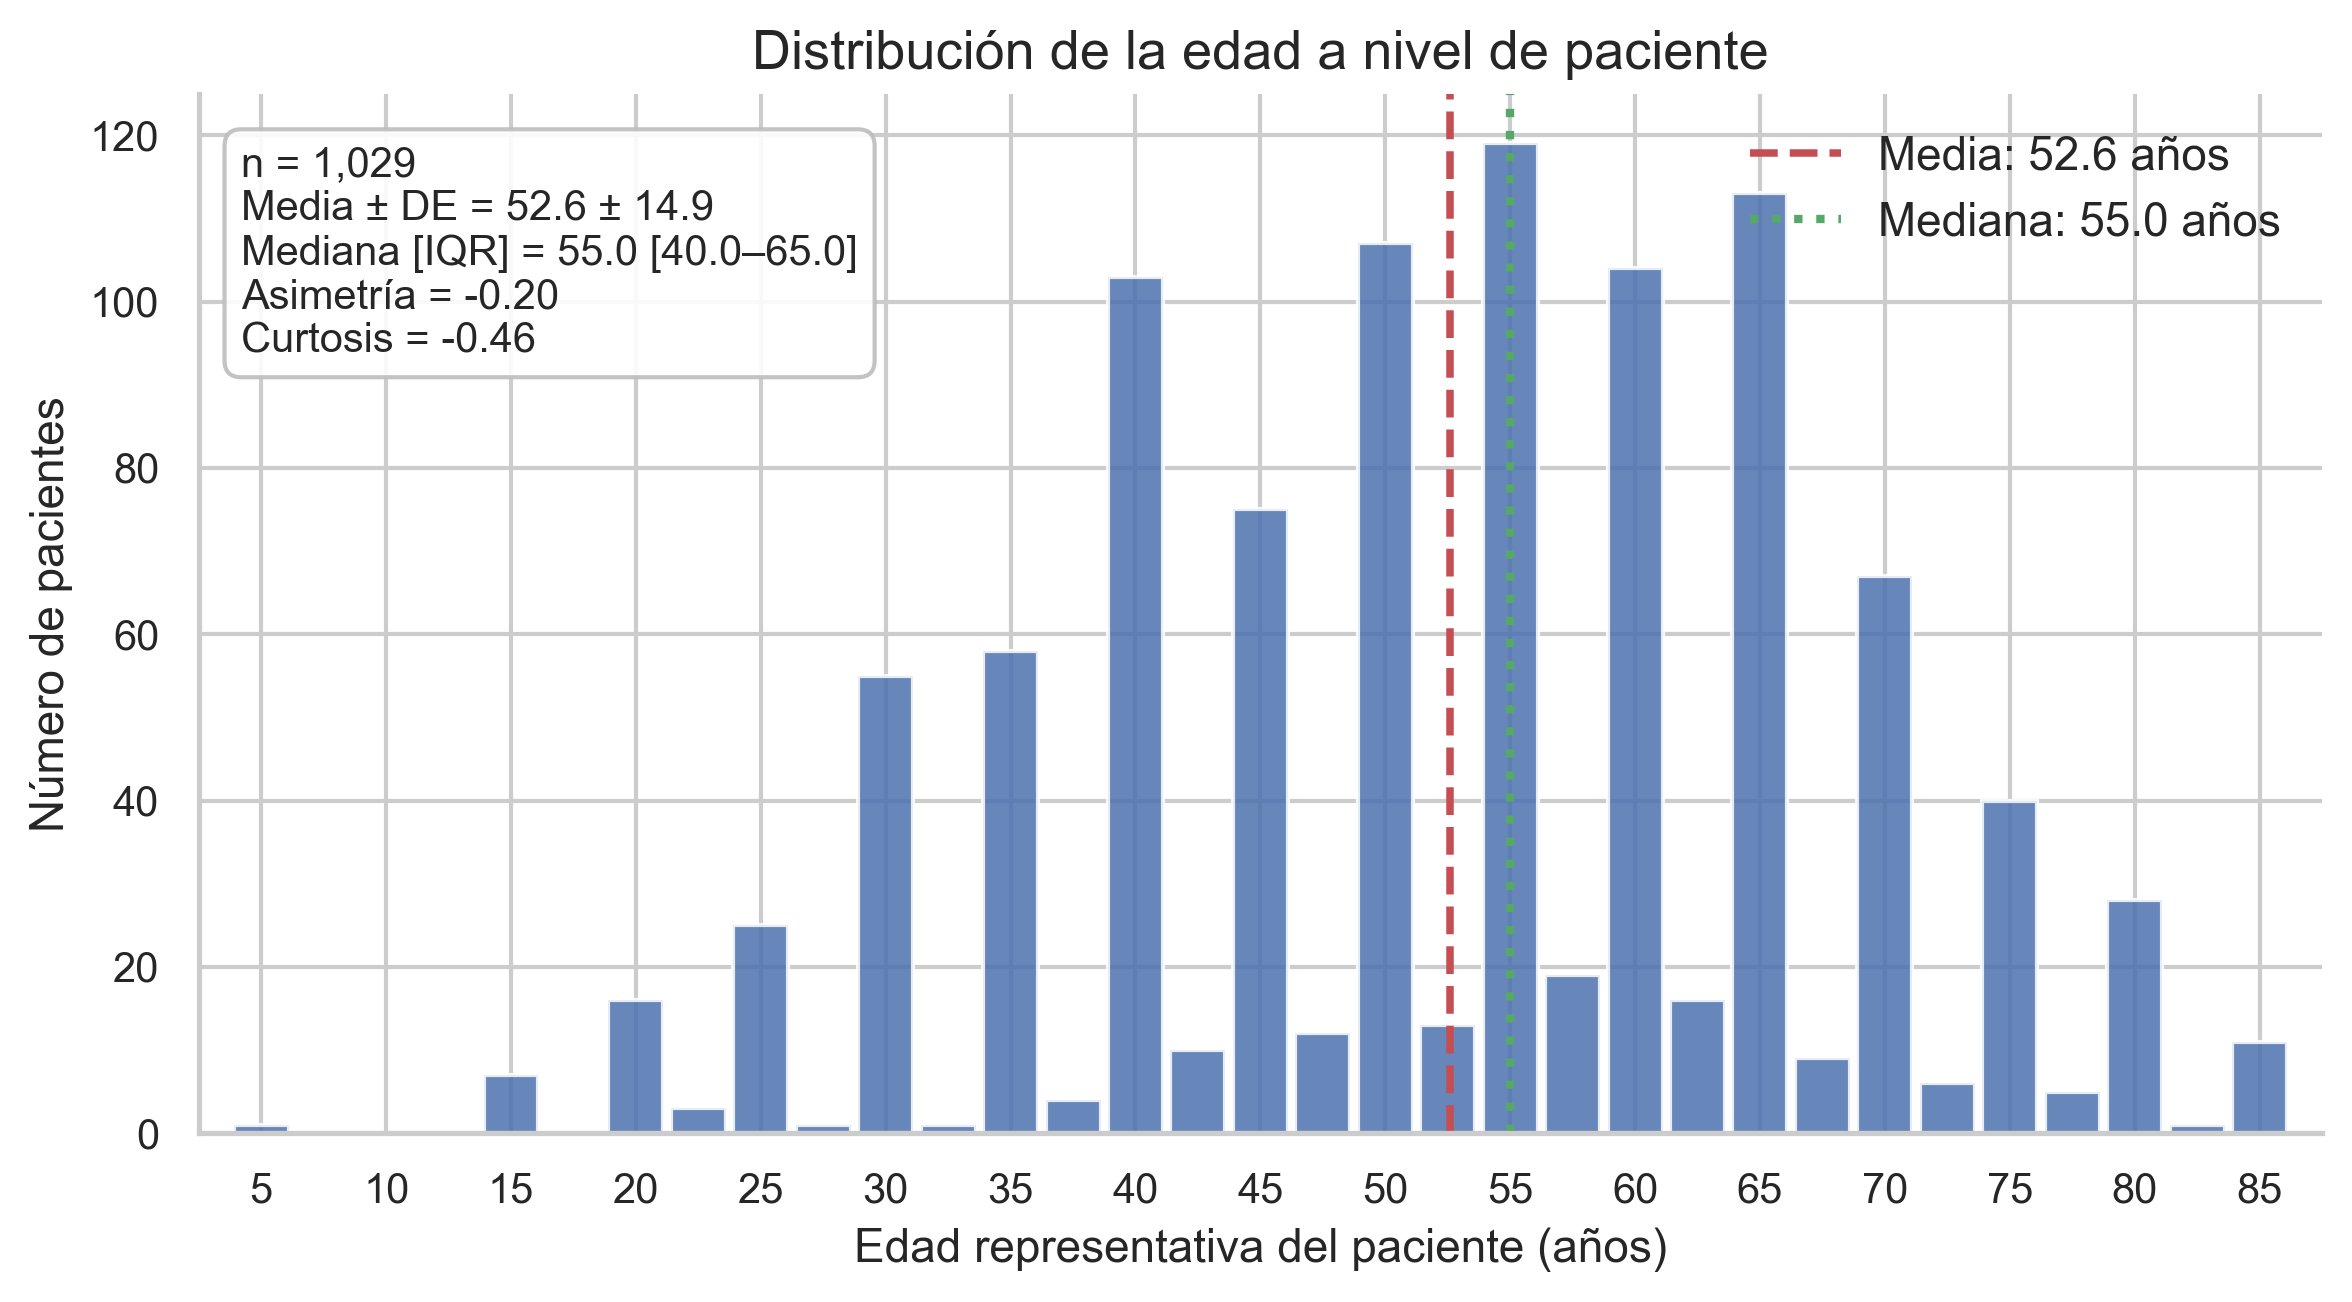

In [89]:
# Age distribution at patient level

fig, ax = plt.subplots(
    figsize=(8, 4.5),
)

ax.bar(
    age_frequency_plot_df["age_patient"],
    age_frequency_plot_df["n_patients"],
    width=2.2,
    color=STATISTIC_PALETTE["distribution"],
    alpha=0.85,
)

# Mean and median
ax.axvline(
    age_mean,
    color=STATISTIC_PALETTE["mean"],
    linestyle="--",
    linewidth=1.8,
    label=f"Media: {age_mean:.1f} años",
)

ax.axvline(
    age_median,
    color=STATISTIC_PALETTE["median"],
    linestyle=":",
    linewidth=2,
    label=f"Mediana: {age_median:.1f} años",
)

# Descriptive statistics box
statistics_text = (
    f"n = {len(age_values):,}\n"
    f"Media ± DE = {age_mean:.1f} ± {age_std:.1f}\n"
    f"Mediana [IQR] = {age_median:.1f} "
    f"[{age_q1:.1f}–{age_q3:.1f}]\n"
    f"Asimetría = {age_skewness:.2f}\n"
    f"Curtosis = {age_kurtosis:.2f}"
)

ax.text(
    0.02,
    0.95,
    statistics_text,
    transform=ax.transAxes,
    ha="left",
    va="top",
    fontsize=10,
    bbox={
        "boxstyle": "round,pad=0.4",
        "facecolor": "white",
        "edgecolor": "#BDBDBD",
        "alpha": 0.9,
    },
)

clean_axis_labels(
    ax,
    xlabel="Edad representativa del paciente (años)",
    ylabel="Número de pacientes",
    title="Distribución de la edad a nivel de paciente",
)

ax.set_xticks(np.arange(5, 90, 5))
ax.set_xlim(2.5, 87.5)

ax.legend(
    frameon=False,
    loc="upper right",
)

plt.tight_layout()
plt.show()

figures["age_distribution_patient_level"] = fig

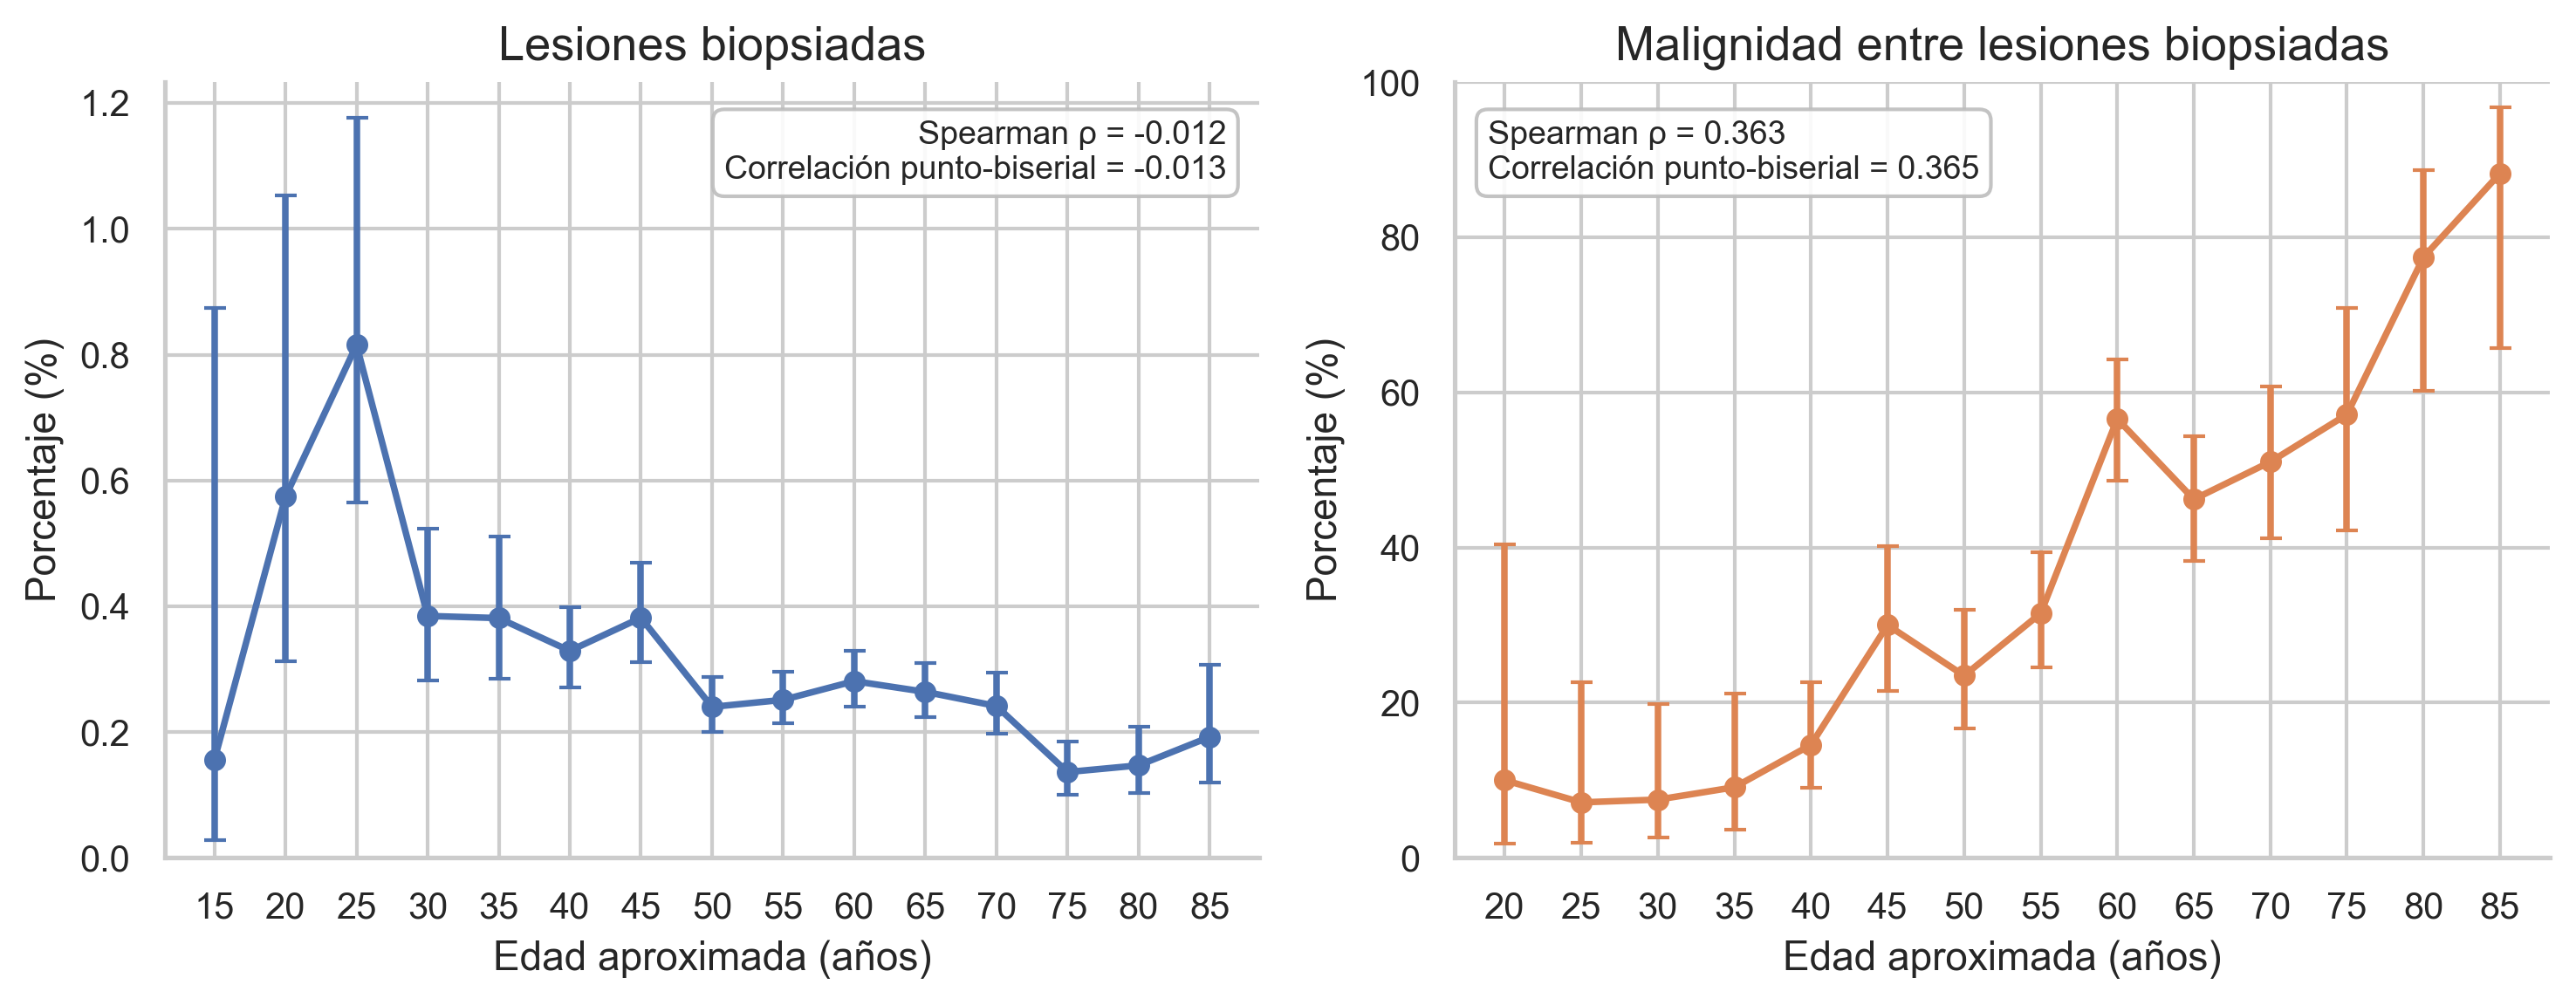

In [83]:
# Age relationship with the two modelling hypotheses

# Exclude age groups with very small denominators only for visualization
age_biopsy_plot_df = (
    age_biopsy_rate.query("n_lesions >= 20").sort_values("age_approx").copy()
)

age_malignancy_plot_df = (
    age_malignancy_rate.query("n_biopsied_lesions >= 10")
    .sort_values("age_approx")
    .copy()
)

fig, axes = plt.subplots(
    1,
    2,
    figsize=(10, 4),
)

# Hypothesis 1: biopsy recommendation

axes[0].errorbar(
    age_biopsy_plot_df["age_approx"],
    age_biopsy_plot_df["biopsy_rate_percentage"],
    yerr=[
        age_biopsy_plot_df["biopsy_rate_percentage"] - age_biopsy_plot_df["ci_lower"],
        age_biopsy_plot_df["ci_upper"] - age_biopsy_plot_df["biopsy_rate_percentage"],
    ],
    fmt="o-",
    color=PREDICTIVE_PALETTE["hypothesis_1"],
    linewidth=1.8,
    markersize=5,
    capsize=3,
)

clean_axis_labels(
    axes[0],
    xlabel="Edad aproximada (años)",
    ylabel="Porcentaje (%)",
    title="Lesiones biopsiadas",
)

axes[0].set_xticks(age_biopsy_plot_df["age_approx"])

axes[0].set_ylim(bottom=0)

axes[0].text(
    0.97,
    0.95,
    "Spearman ρ = -0.012\nCorrelación punto-biserial = -0.013",
    transform=axes[0].transAxes,
    ha="right",
    va="top",
    fontsize=9,
    bbox={
        "boxstyle": "round,pad=0.35",
        "facecolor": "white",
        "edgecolor": "#BDBDBD",
        "alpha": 0.9,
    },
)

# Hypothesis 2: malignancy classification


axes[1].errorbar(
    age_malignancy_plot_df["age_approx"],
    age_malignancy_plot_df["malignancy_rate_percentage"],
    yerr=[
        age_malignancy_plot_df["malignancy_rate_percentage"]
        - age_malignancy_plot_df["ci_lower"],
        age_malignancy_plot_df["ci_upper"]
        - age_malignancy_plot_df["malignancy_rate_percentage"],
    ],
    fmt="o-",
    color=PREDICTIVE_PALETTE["hypothesis_2"],
    linewidth=1.8,
    markersize=5,
    capsize=3,
)

clean_axis_labels(
    axes[1],
    xlabel="Edad aproximada (años)",
    ylabel="Porcentaje (%)",
    title="Malignidad entre lesiones biopsiadas",
)

axes[1].set_xticks(age_malignancy_plot_df["age_approx"])

axes[1].set_ylim(0, 100)

axes[1].text(
    0.03,
    0.95,
    "Spearman ρ = 0.363\nCorrelación punto-biserial = 0.365",
    transform=axes[1].transAxes,
    ha="left",
    va="top",
    fontsize=9,
    bbox={
        "boxstyle": "round,pad=0.35",
        "facecolor": "white",
        "edgecolor": "#BDBDBD",
        "alpha": 0.9,
    },
)

plt.tight_layout()
plt.show()

figures["age_predictive_value"] = fig

In [84]:
# Plot data: missing age by attribution

age_missing_attribution_plot_df = age_missing_by_attribution.copy()

age_missing_attribution_plot_df["attribution_label"] = simplify_attribution_series(
    age_missing_attribution_plot_df["attribution"]
)

age_missing_attribution_plot_df["label"] = (
    age_missing_attribution_plot_df["perc_patients_missing_age"].map("{:.2f}%".format)
    + " ("
    + age_missing_attribution_plot_df["n_patients_missing_age"].astype(int).astype(str)
    + "/"
    + age_missing_attribution_plot_df["n_patients_total"].astype(int).astype(str)
    + ")"
)

age_missing_attribution_plot_df = age_missing_attribution_plot_df.sort_values(
    "perc_patients_missing_age",
    ascending=True,
)

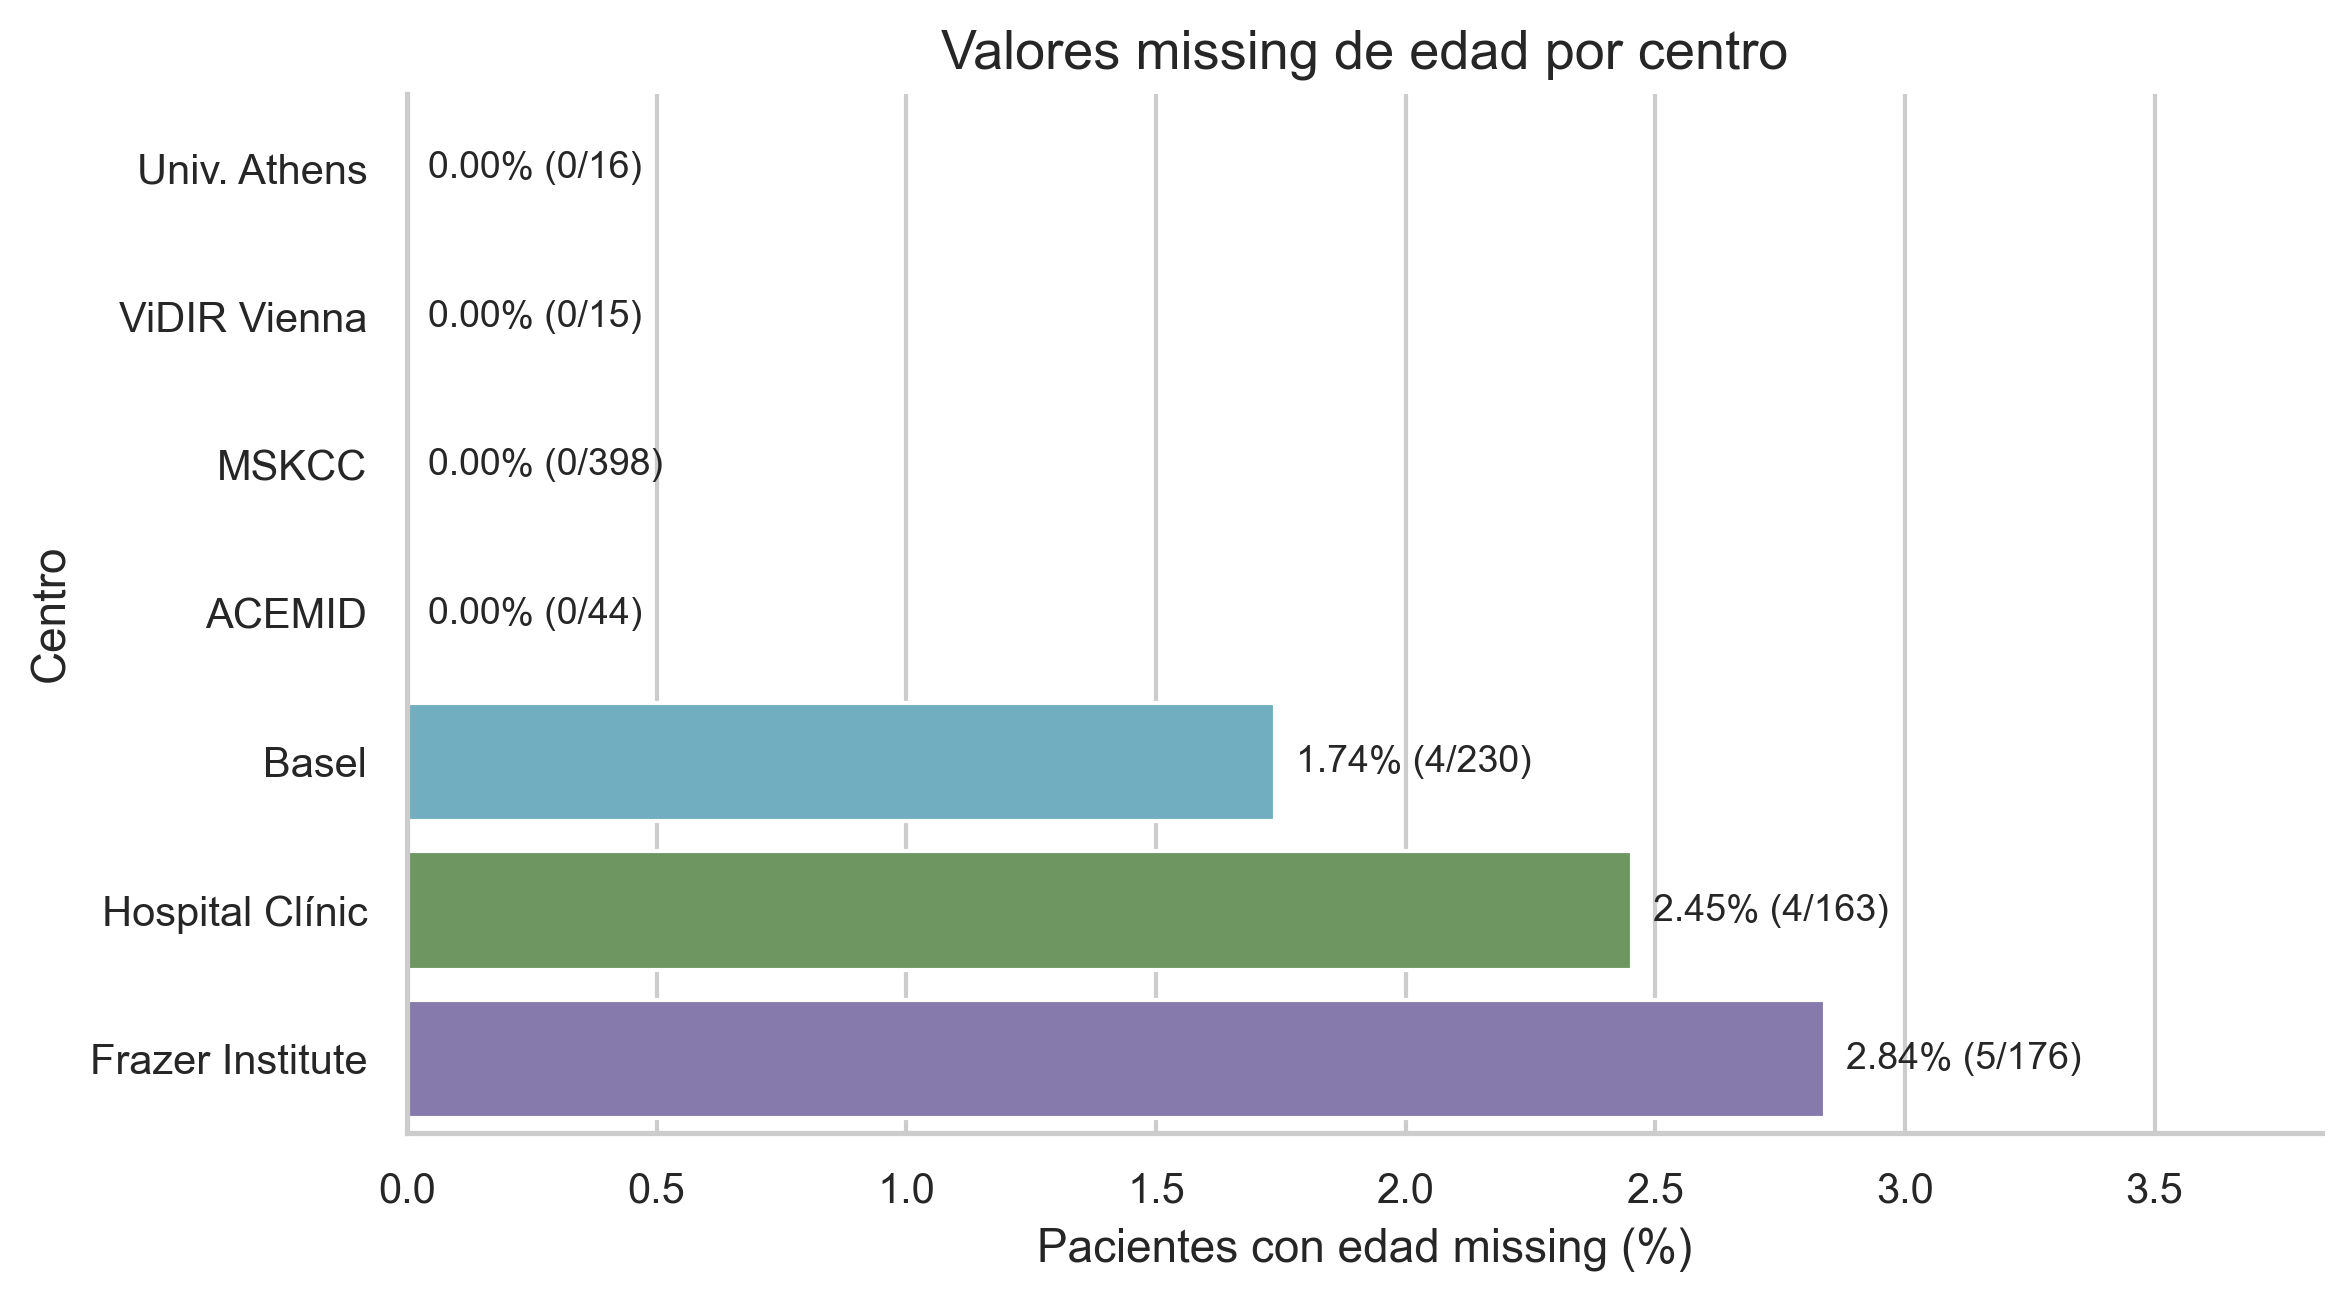

In [85]:
# Missing age by attribution

fig, ax = plt.subplots(
    figsize=(8, 4.5),
)

sns.barplot(
    data=age_missing_attribution_plot_df,
    x="perc_patients_missing_age",
    y="attribution_label",
    hue="attribution_label",
    palette=ATTRIBUTION_PALETTE,
    legend=False,
    ax=ax,
)

# Add percentage and count labels
for patch, (_, row) in zip(
    ax.patches,
    age_missing_attribution_plot_df.iterrows(),
):
    width = patch.get_width()

    # Also label centres with no missing values
    x_position = width if width > 0 else 0

    ax.annotate(
        row["label"],
        xy=(
            x_position,
            patch.get_y() + patch.get_height() / 2,
        ),
        xytext=(5, 0),
        textcoords="offset points",
        ha="left",
        va="center",
        fontsize=9,
    )

clean_axis_labels(
    ax,
    xlabel="Pacientes con edad missing (%)",
    ylabel="Centro",
    title="Valores missing de edad por centro",
)

max_percentage = age_missing_attribution_plot_df["perc_patients_missing_age"].max()

ax.set_xlim(
    0,
    max_percentage * 1.35,
)

plt.tight_layout()
plt.show()

figures["age_missing_attribution"] = fig

# ANATOMICAL SITE

# LESION SIZE

# FINAL SUMMARY

## Variable 'sex'

La variable `sex` representa el sexo biológico del paciente. Se trata de una variable cualitativa binaria, almacenada en formato `string` y registrada a nivel de lesión, aunque conceptualmente corresponde a un atributo de nivel paciente. El conjunto de datos contiene **401,059 lesiones** correspondientes a **1,042 pacientes**.

La variable presenta dos categorías observadas (`female` y `male`) además de un pequeño porcentaje de valores missing. La distribución muestra un predominio masculino tanto a nivel de lesión como de paciente.

| Sexo      | Lesiones (n) | % lesiones | Pacientes (n) | % pacientes | Lesiones biopsiadas (n) | % biopsiadas | Lesiones malignas (n)            | % malignas entre biopsiadas |
| --------- | -----------: | ---------: | ------------: | ----------: | ----------------------: | -----------: | -------------------------------: | --------------------------: |
| female    |      123,996 |      30.92 |           458 |       43.95 |                     400 |         0.32 |                              109 |                       27.25 |
| male      |      265,546 |      66.21 |           551 |       52.88 |                     636 |         0.24 |                              274 |                       43.08 |
| Missing   |       11,517 |       2.87 |            33 |        3.17 |                      32 |         0.28 |                               10 |                       31.25 |
| **Total** |  **401,059** | **100.00** |     **1,042** |  **100.00** |               **1,068** |     **0.27** |                          **393** |                   **36.80** |

En relación con las variables objetivo, `sex` muestra comportamientos distintos según la tarea predictiva considerada.

| Análisis                                 | p-value χ² | V de Cramér | Interpretación                                 |
| ---------------------------------------- | ---------: | ----------: | ---------------------------------------------- |
| Sex vs biopsia                           | 1.6457e-05 |      0.0074 | Asociación prácticamente nula                  |
| Sex vs malignidad en lesiones biopsiadas | 1.4406e-06 |      0.1587 | Asociación débil pero potencialmente relevante |

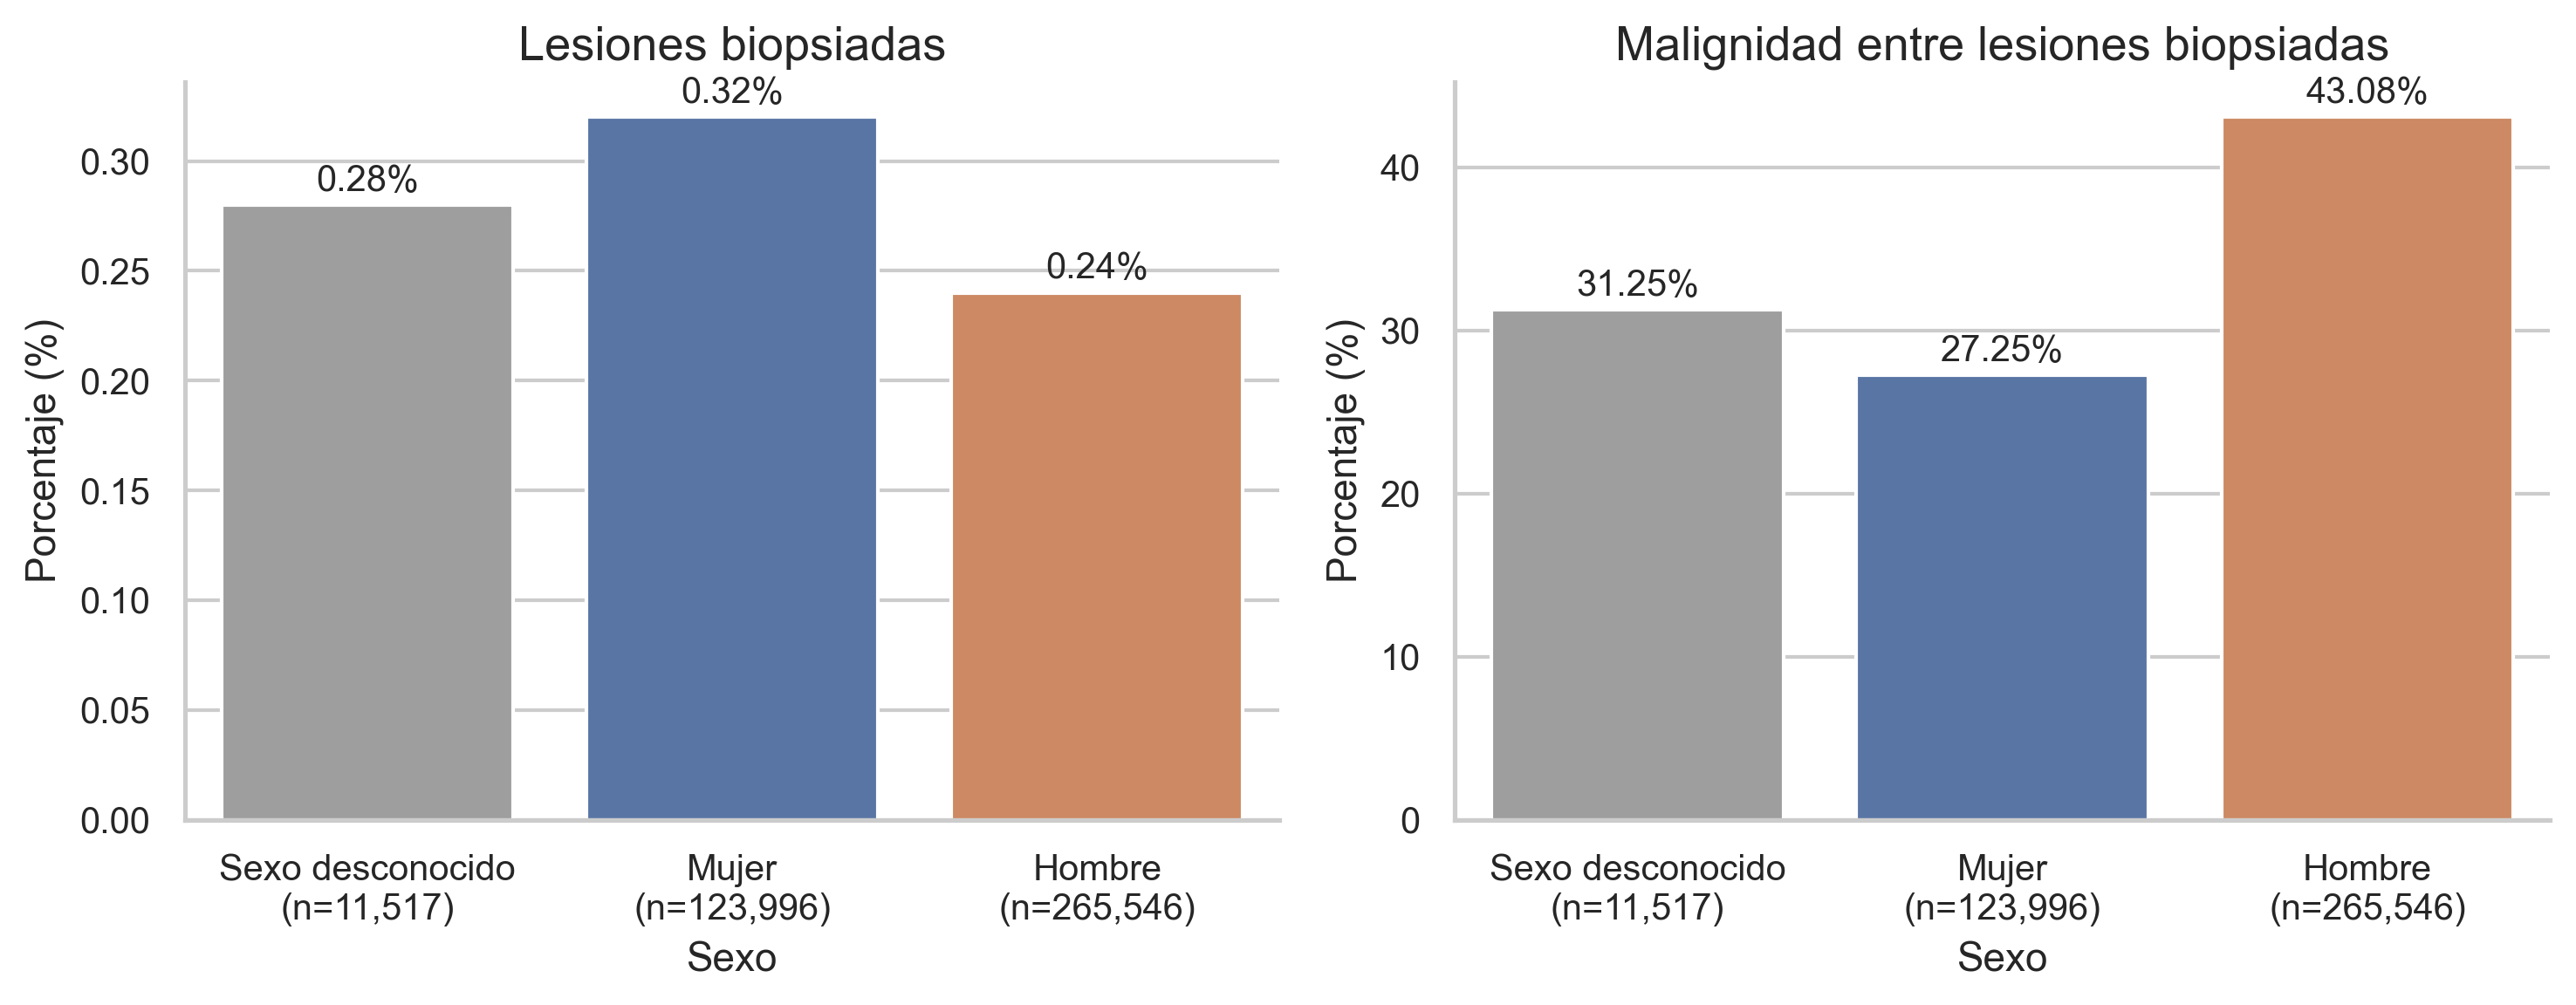

In [79]:
figures["sex_predictive_value"]

Para evaluar la asociación entre `sex` y las variables objetivo se emplean dos métricas complementarias. En primer lugar, se utiliza el test χ² de independencia para determinar si existe evidencia estadística de asociación entre las variables. Sin embargo, dado el elevado tamaño muestral disponible, pequeñas diferencias pueden resultar estadísticamente significativas aun careciendo de relevancia práctica. Por este motivo, la interpretación principal se basa en la V de Cramér, una medida de tamaño del efecto comprendida entre 0 y 1, donde valores próximos a 0 indican ausencia de asociación y valores crecientes reflejan asociaciones progresivamente más fuertes.

La asociación entre `sex` y la decisión de biopsiar una lesión resulta estadísticamente significativa, pero presenta una magnitud prácticamente nula (V de Cramér = 0.0074). Las proporciones de lesiones biopsiadas son muy similares entre mujeres (0.32%) y hombres (0.24%), lo que sugiere que el sexo aporta escasa información para discriminar entre lesiones biopsiadas y no biopsiadas.

Por el contrario, entre las lesiones ya biopsiadas se observa una asociación más marcada con la malignidad (V de Cramér = 0.1587). Las lesiones biopsiadas de pacientes masculinos presentan una proporción de malignidad sustancialmente superior a la observada en pacientes femeninos (43.08% frente a 27.25%), lo que sugiere que `sex` podría aportar información útil en modelos orientados a diferenciar lesiones malignas y no malignas.

Desde un punto de vista clínico, la literatura médica describe diferencias relevantes entre hombres y mujeres en la distribución anatómica de las lesiones cutáneas y de los tumores malignos. Por este motivo, aunque la asociación directa observada con algunas variables objetivo sea limitada, sex podría aportar información complementaria cuando se analiza conjuntamente con la localización de la lesión.

Respecto a los valores missing, estos afectan a 11,517 lesiones (2.87%) correspondientes a 33 pacientes (3.17%). La ausencia de información es completamente consistente a nivel de paciente: todos los pacientes afectados presentan la variable `sex` ausente en la totalidad de sus lesiones.

La distribución de los valores missing no es homogénea entre centros, sino que se concentra principalmente en el University Hospital of Basel y, en menor medida, en el Frazer Institute. Este patrón sugiere que la ausencia de información está probablemente relacionada con diferencias en los procedimientos de recogida, integración o anonimización de datos, más que con características clínicas propias de los pacientes o de las lesiones. Además, los pacientes con `sex` missing no presentan diferencias clínicamente relevantes en edad ni en distribución diagnóstica respecto al resto de la cohorte.

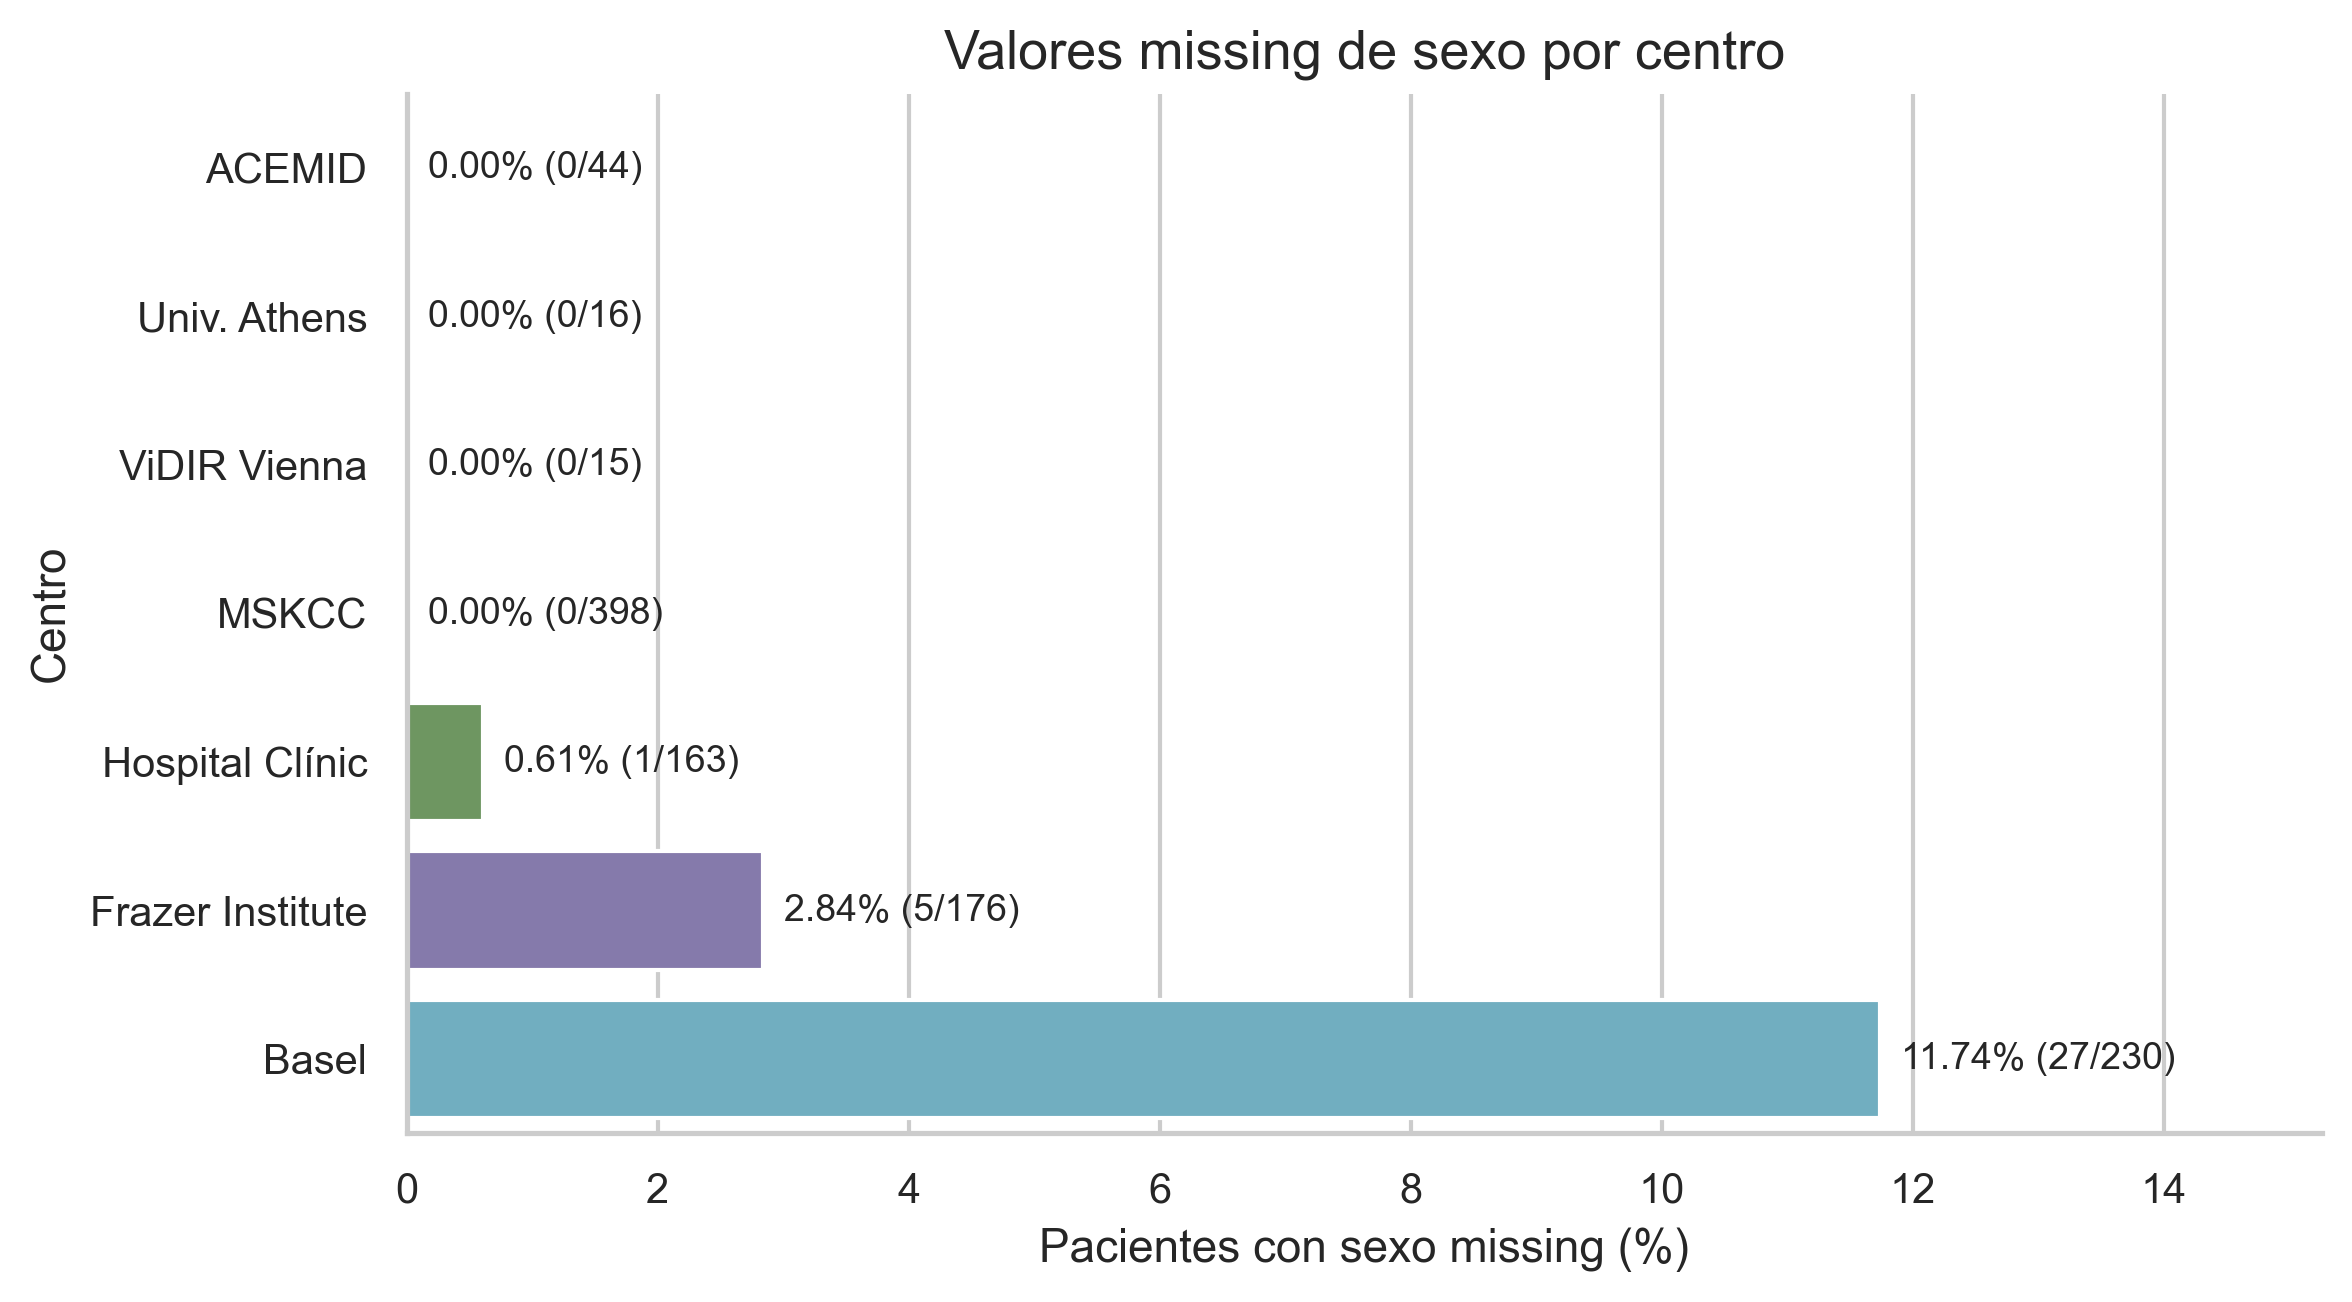

In [76]:
figures["sex_missing_attribution"]

En conjunto, la evidencia disponible sugiere que el mecanismo de ausencia es más compatible con un patrón Missing At Random (MAR) asociado al centro de procedencia (`attribution`) que con un mecanismo Missing Not At Random (MNAR). Bajo esta hipótesis, tanto la imputación como la eliminación de los pacientes afectados podrían considerarse estrategias de preprocesamiento. Sin embargo, dado el reducido porcentaje de valores missing, la ausencia de evidencias de sesgos clínicamente relevantes y el impacto potencialmente limitado de una imputación basada en un número reducido de variables disponibles, la eliminación de estos pacientes constituye una alternativa simple, siempre que no altere de forma apreciable la composición clínica del conjunto de datos.

Para evaluar el impacto potencial de esta decisión se compara la distribución global del dataset antes y después de eliminar los pacientes con valores missing en `sex`.

| Escenario                                 | Pacientes (n) | Pacientes (%) | Lesiones (n) | Lesiones (%) |
| ----------------------------------------- | ------------: | ------------: | -----------: | -----------: |
| Dataset original                          |         1,042 |        100.00 |      401,059 |       100.00 |
| Tras eliminar pacientes con `sex` missing |         1,009 |         96.83 |      389,542 |        97.13 |
| Registros eliminados                      |            33 |          3.17 |       11,517 |         2.87 |



| Categoría diagnóstica  | Antes (%) | Después (%) | Diferencia (pp) |
| ---------------------- | --------: | ----------: | --------------: |
| Benign non-biopsied    |   99.7337 |     99.7340 |         +0.0003 |
| Benign biopsied        |    0.1399 |      0.1397 |         -0.0002 |
| Indeterminate biopsied |    0.0284 |      0.0280 |         -0.0004 |
| Malignant biopsied     |    0.0980 |      0.0983 |         +0.0003 |

Los cambios observados son inferiores a 0.0005 puntos porcentuales en todas las categorías diagnósticas analizadas, sin modificar de forma apreciable la composición clínica del conjunto de datos ni el grado de desbalanceo de las categorías de la variable objetivo. En consecuencia, se recomienda eliminar estos pacientes antes del entrenamiento de los modelos. Dado el reducido número de pacientes afectados y el impacto prácticamente nulo de su exclusión sobre la composición del conjunto de datos, esta estrategia evita introducir complejidad adicional mediante procedimientos de imputación, simplifica el tratamiento posterior de la variable y evita la creación de una categoría artificial (Unknown) con escasa representación y valor predictivo incierto.

Los pacientes a eliminar serían:

`IP_3371534`, `IP_6187331`, `IP_9472195`, `IP_2914511`, `IP_5044083`, `IP_6207479`, `IP_6975913`, `IP_1241473`, `IP_5887935`, `IP_8810058`, `IP_8999199`, `IP_6732258`, `IP_6413837`, `IP_1474479`, `IP_0797650`, `IP_2148283`, `IP_4579352`, `IP_7563441`, `IP_1715157`, `IP_1016097`, `IP_7703522`, `IP_4080836`, `IP_8377208`, `IP_1822913`, `IP_6193088`, `IP_0473747`, `IP_1433033`, `IP_6709102`, `IP_8036435`, `IP_2075317`, `IP_7858959`, `IP_9550509` e `IP_5373245`.

Finalmente, se recomienda codificarla mediante una representación binaria (`0/1`) para facilitar su utilización en los modelos de machine learning posteriores.

## Variable 'age_approx'

La variable `age_approx` representa la edad aproximada del paciente en el momento de adquisición de la imagen. Es una variable cuantitativa continua por naturaleza, aunque aparece discretizada principalmente en intervalos de cinco años. Está registrada a nivel de lesión, pero conceptualmente corresponde a una característica del paciente.

De los 1,042 pacientes, 929 presentan una única edad registrada, 100 presentan dos edades separadas por exactamente cinco años y 13 no disponen de información. Para los análisis descriptivos a nivel de paciente se utilizó el punto medio entre ambas edades cuando existían dos valores. Sin embargo, para el modelado se recomienda conservar la edad original asociada a cada lesión, ya que refleja adquisiciones realizadas en momentos distintos.

| Nivel    | No nulos |    Media ± DE | Mediana [IQR] | Rango | Skewness | Kurtosis |
| -------- | -------: | ------------: | ------------: | ----: | -------: | -------: |
| Lesión   |  398,261 | 58.01 ± 13.60 |    60 [50–70] |  5–85 |    -0.26 |    -0.29 |
| Paciente |    1,029 | 52.61 ± 14.92 |    55 [40–65] |  5–85 |    -0.20 |    -0.46 |

La edad media es superior a nivel de lesión, lo que indica que los pacientes de mayor edad aportan más imágenes. La distribución presenta únicamente una ligera asimetría negativa y no muestra colas extremas ni valores clínicamente inverosímiles. Las edades de 5 y 15 años se identifican como outliers mediante la regla del IQR a nivel de lesión, pero no existen motivos para considerarlas errores.


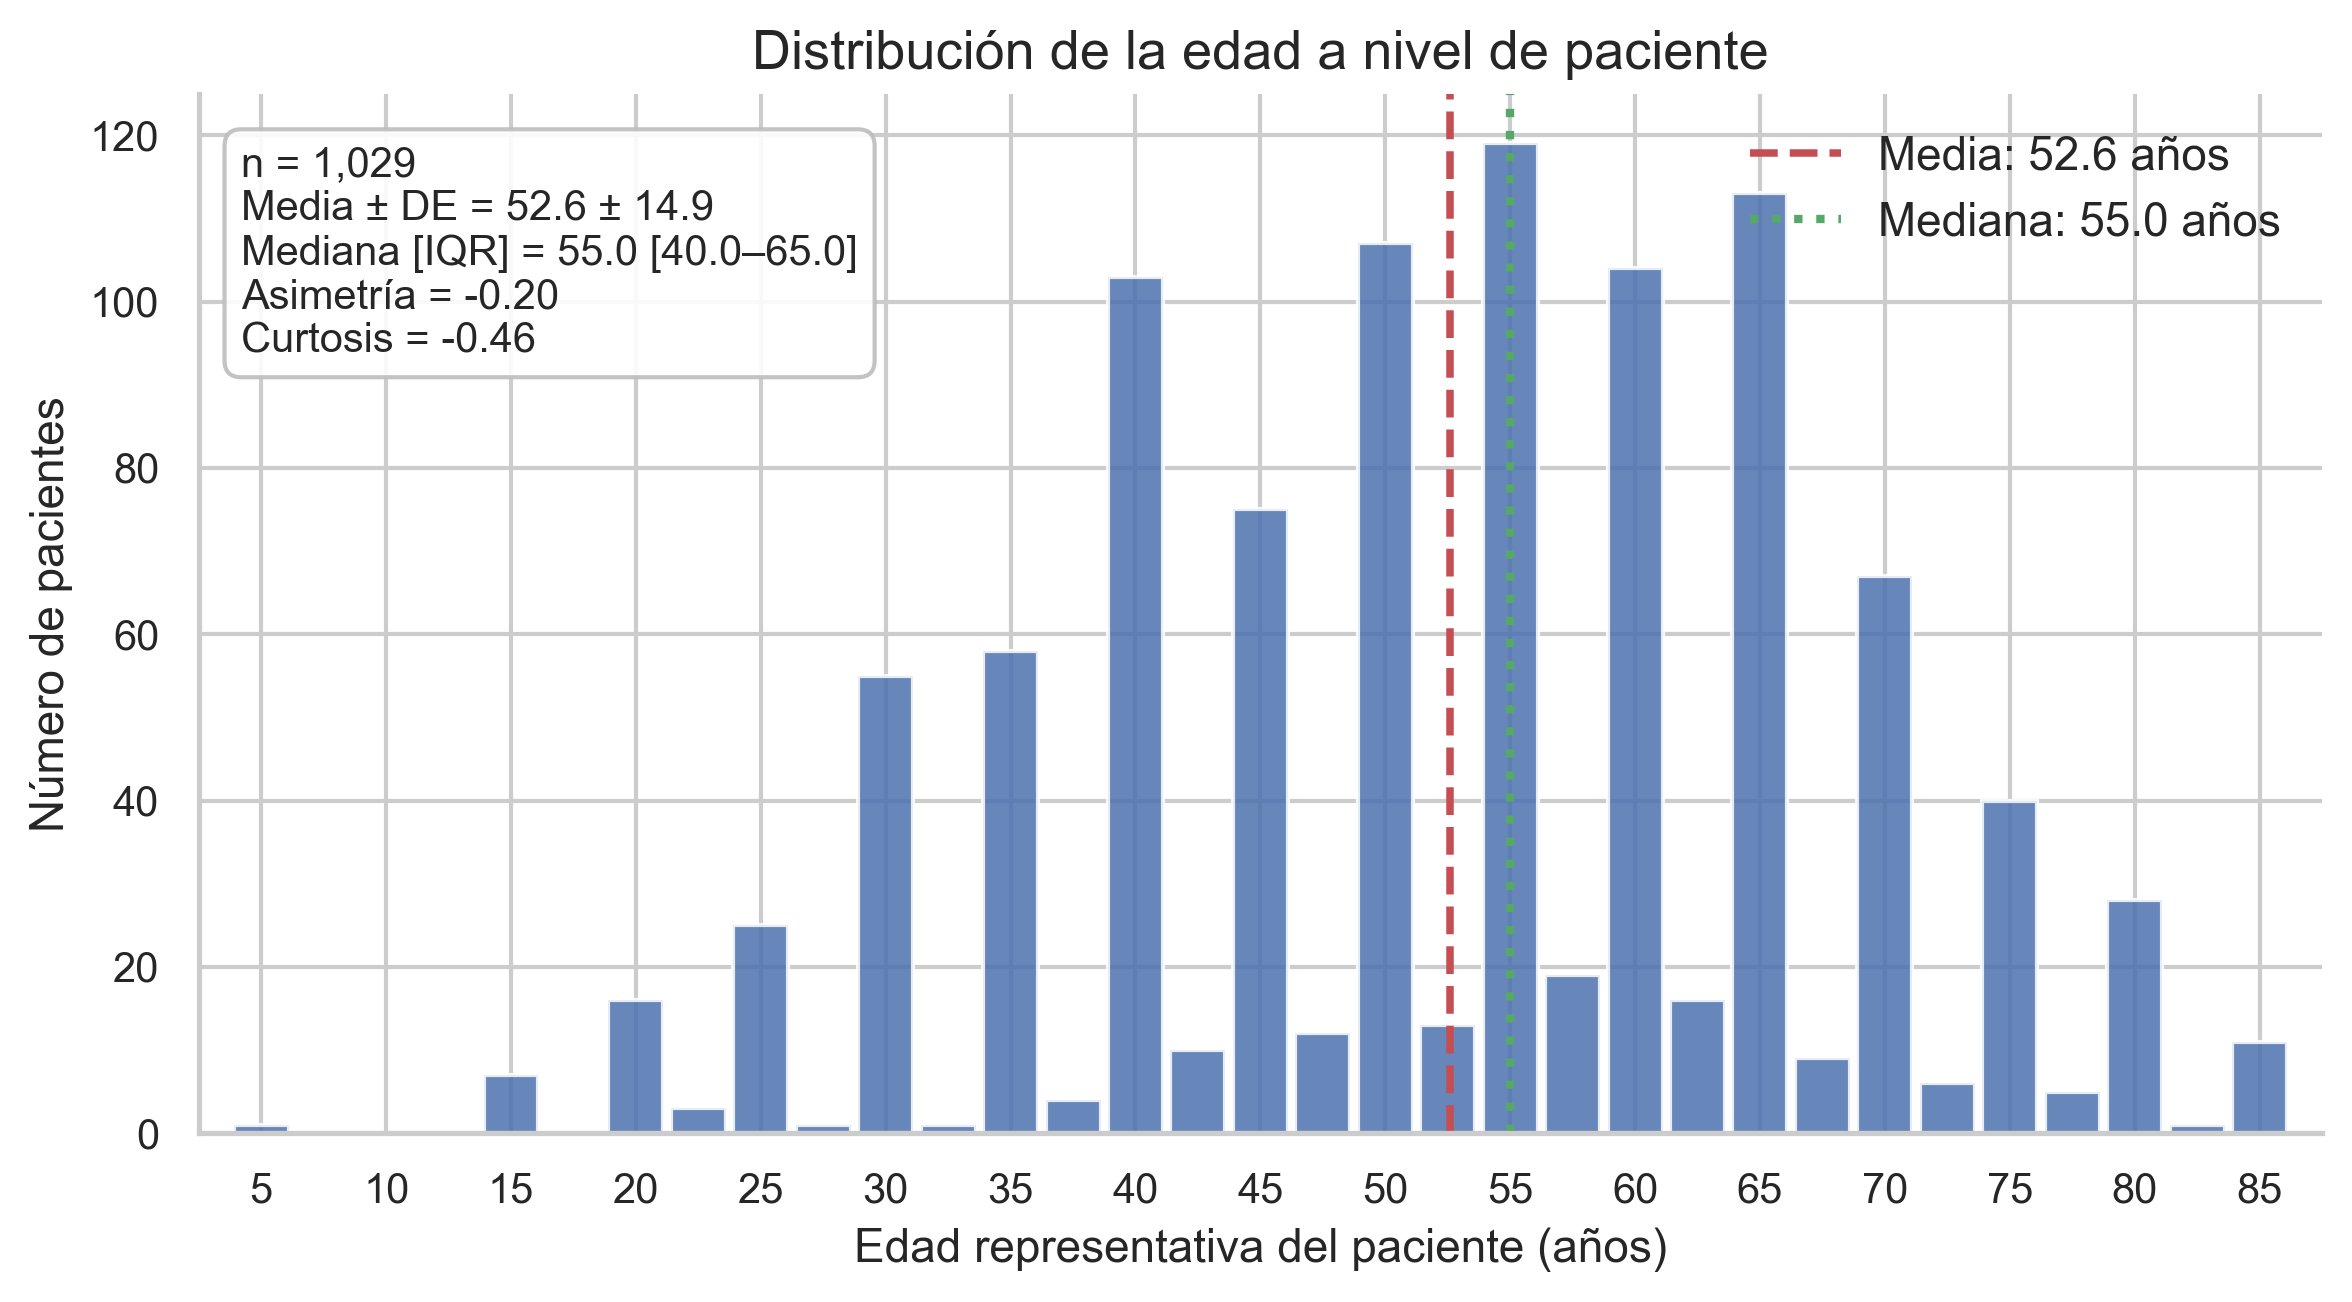

In [90]:
figures["age_distribution_patient_level"]

La relación con las variables objetivo difiere claramente entre las dos hipótesis de modelado:

| Análisis                            | Mediana grupo negativo | Mediana grupo positivo | Mann–Whitney p | Correlación punto-biserial | Spearman | Interpretación                |
| ----------------------------------- | ---------------------: | ---------------------: | -------------: | -------------------------: | -------: | ----------------------------- |
| Edad vs biopsia                     |                     60 |                     55 |         <0.001 |                    -0.0127 |  -0.0117 | Asociación prácticamente nula |
| Edad vs malignidad entre biopsiadas |                     50 |                     60 |         <0.001 |                     0.3653 |   0.3627 | Asociación positiva moderada  |

Se utiliza la prueba de Mann–Whitney U porque la edad está discretizada, contiene numerosos valores repetidos y los tamaños de los grupos son muy diferentes. Dado el elevado tamaño muestral, los valores p se interpretaron junto con medidas de tamaño del efecto. La correlación punto-biserial evalúa la relación lineal entre la edad y un target binario, mientras que Spearman permite detectar relaciones monotónicas sin asumir linealidad.


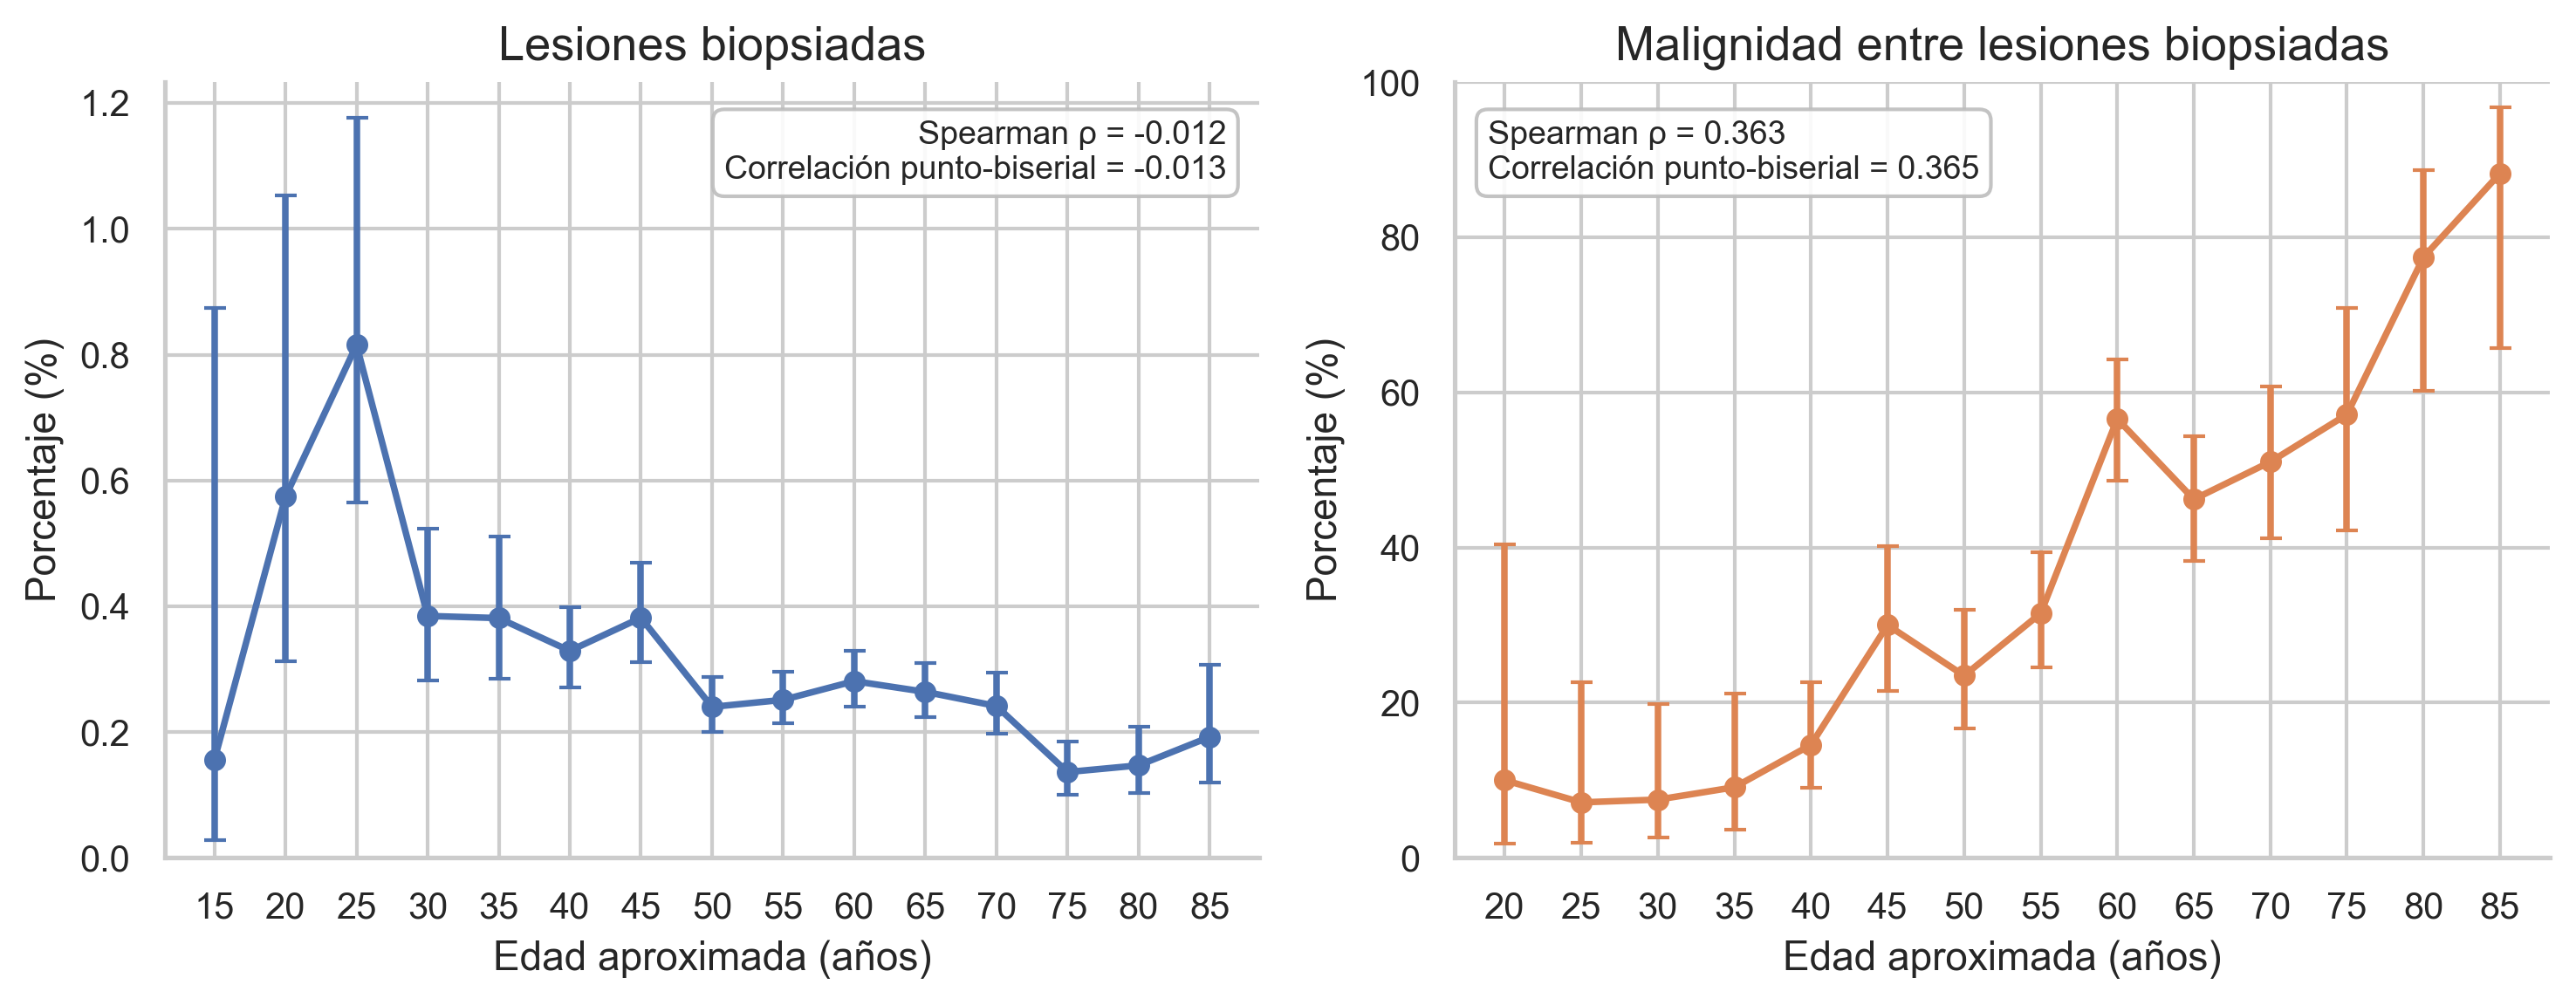

In [87]:
figures["age_predictive_value"]

En el modelo de recomendación de biopsia, la edad aporta muy poca capacidad discriminativa. En cambio, entre las lesiones biopsiadas se observa un aumento claro de la proporción de malignidad con la edad, por lo que `age_approx` puede ser una variable relevante para la segunda hipótesis.

Respecto a los valores missing, estos afectan a 2,798 lesiones correspondientes a 13 pacientes. En todos ellos la edad está ausente en la totalidad de sus lesiones.

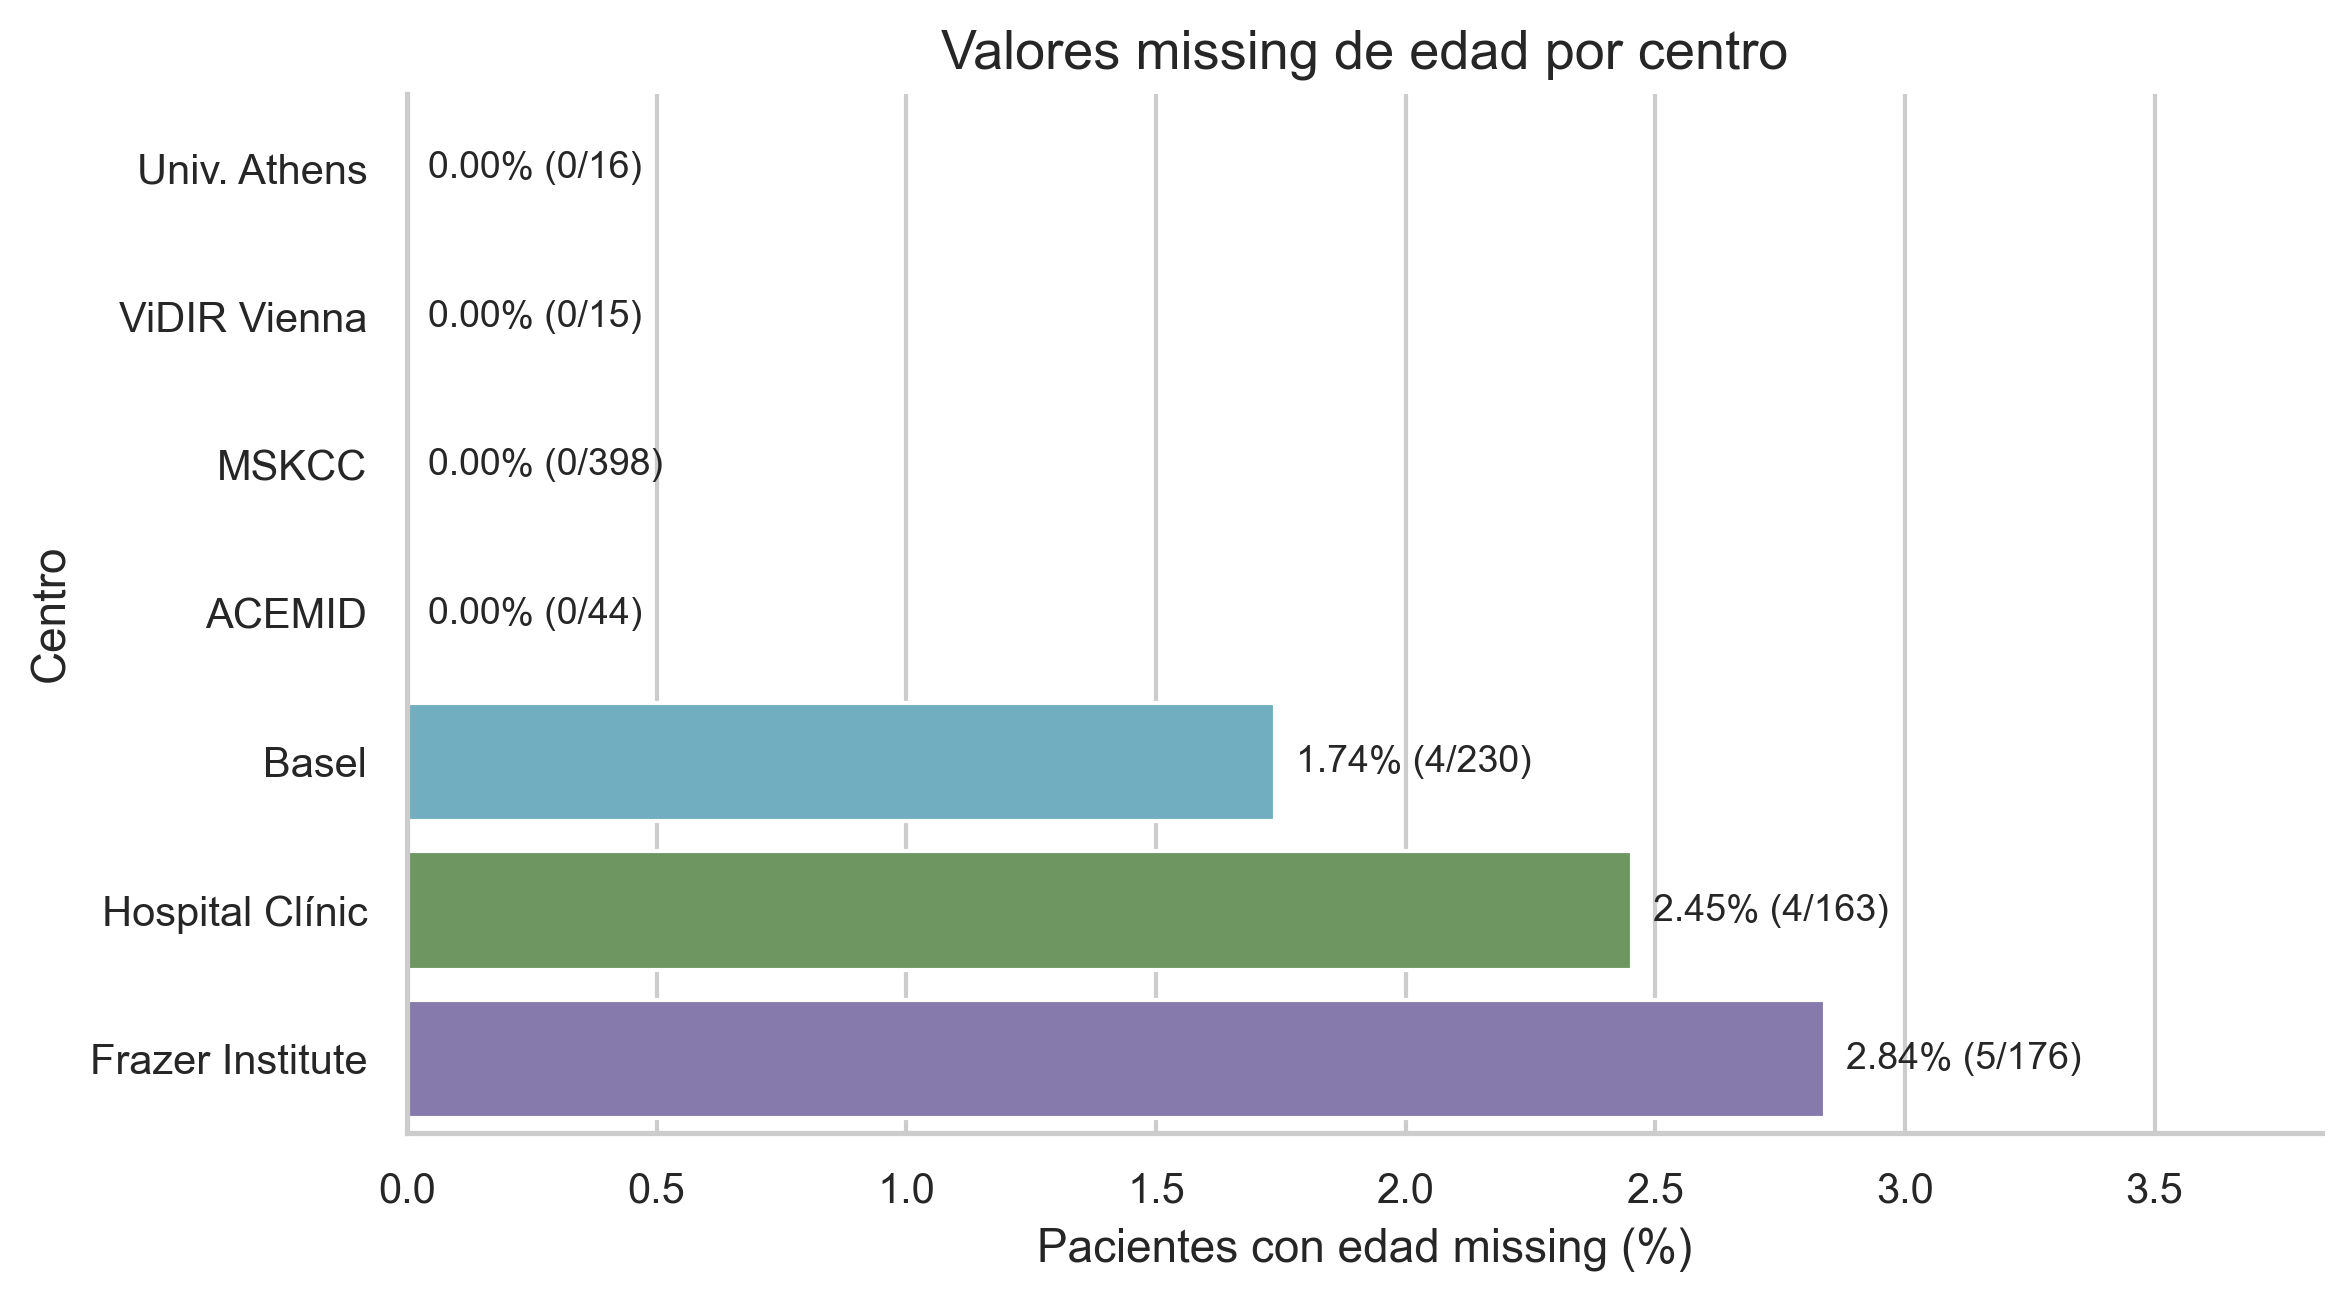

In [86]:
figures["age_missing_attribution"]

Los casos se concentran exclusivamente en el Frazer Institute, el Hospital Clínic y el University Hospital of Basel, y presentan una mayor frecuencia de ausencia simultánea de otras variables. Este patrón no parece completamente aleatorio y es compatible, de forma orientativa, con un mecanismo MAR relacionado con el centro y con la disponibilidad general de metadatos. No obstante, este supuesto no puede demostrarse únicamente mediante el análisis exploratorio.

| Impacto de eliminar los pacientes con edad missing |  Pacientes |      Lesiones |
| -------------------------------------------------- | ---------: | ------------: |
| Dataset original                                   |      1,042 |       401,059 |
| Dataset resultante                                 |      1,029 |       398,261 |
| Registros eliminados                               | 13 (1.25%) | 2,798 (0.70%) |

Las lesiones eliminadas incluyen 2,794 lesiones benignas no biopsiadas, una lesión indeterminada biopsiada y tres lesiones malignas biopsiadas. Dado el reducido impacto global y la ausencia completa de edad a nivel de paciente, se recomienda eliminar estos 13 pacientes en lugar de imputar una edad artificial.

No se recomienda aplicar transformaciones logarítmicas ni eliminar valores extremos. La variable debería mantenerse como cuantitativa continua discretizada y estandarizarse únicamente en algoritmos sensibles a la escala. También conviene evaluar posibles relaciones no lineales, especialmente en el modelo de malignidad.

Finalmente, existen ocho pacientes con edades inferiores a 18 años. Su exclusión no debería justificarse como tratamiento de outliers, sino como una decisión sobre el ámbito clínico del modelo. Si el objetivo se define específicamente para población adulta, resulta razonable excluirlos para evitar mezclar patrones pediátricos y adultos en una cohorte donde la representación infantil es muy limitada. En caso contrario, pueden conservarse, aunque el rendimiento del modelo en población pediátrica no podría evaluarse de forma fiable.

## Variable 'anatom_site_general'

## Variable 'clin_size_long_diam_mm'